# Firedrake Colab "installation"


In [ ]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

--2026-04-15 14:39:34--  https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4767 (4.7K) [application/x-sh]
Saving to: ‘/tmp/firedrake-install.sh’

/tmp/firedrake-inst 100%[===================>]   4.66K  --.-KB/s    in 0s      

2026-04-15 14:39:34 (45.2 MB/s) - ‘/tmp/firedrake-install.sh’ saved [4767/4767]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FIREDRAKE_INSTALLED=/usr/local/share/fem-on-colab/firedrake.installed
+ [[ ! -f /usr/local/share/fem-on-colab/firedrake.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/dff9

In [ ]:
from google.colab import drive
import sys
import os

drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Project Napdes'

if project_path not in sys.path:
    sys.path.append(project_path)

Mounted at /content/drive


In [ ]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np

from firedrake.petsc import PETSc

!pip install gmsh

!apt-get update && apt-get install -y libglu1-mesa

!pip install h5py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 MB 36.8 MB/s eta 0:00:00
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.7 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,968 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.0 MB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,311 kB]
Get:

# From here on, we implement **Firedrake** :

# Definition of the Obstacles

In [ ]:
from firedrake import *
import numpy as np

from math import pi as PI

class circleObstacle:
    def __init__(self, mesh, t_param, x, y, r, riis_epsilon=0.05):
        self.mesh = mesh
        self.t = t_param
        self.x0 = x
        self.y0 = y
        self.r = r
        self.eps = riis_epsilon

        # Spatial Coordinates of the mesh
        self.X = SpatialCoordinate(self.mesh)

        # Amplitude and movement parameters
        self.amplitude = 12 * self.r

        # Displacement Functions
        self.displ_x = self.amplitude * 0.5 * (1 - cos(0.2 * PI * self.t))
        self.displ_y = 0.0

        # Obstacle Velocity
        self.us_x = self.amplitude * 0.1 * PI * sin(0.2 * PI * self.t)
        self.us_y = 0.0

    def distExpr(self):
        """Expression of the Signed Distance Function (SDF)"""
        # Posizione corrente del centro
        xc = self.x0 + self.displ_x
        yc = self.y0 + self.displ_y

        # Euclidean distance from the center
        return sqrt((self.X[0] - xc)**2 + (self.X[1] - yc)**2) - self.r

    def chi(self):
        """Characteristic Function for the Brinkman Method"""
        d = self.distExpr()
        # For discontinuity
        return conditional(d < 0, 1.0, 0.0)

    def delta(self):
        """Dirac Function for RIIS"""
        d = self.distExpr()
        expr = (1 + cos(PI * d / self.eps)) / (2 * self.eps)
        return conditional(abs(d) < self.eps, expr, 0.0)


class lineObstacle:
    def __init__(self, mesh, t_param, xA, yA, xB, yB, riis_epsilon):
        self.mesh = mesh
        self.t = t_param
        self.X = SpatialCoordinate(self.mesh)

        self.A_init = as_vector([xA, yA])
        self.B_init = as_vector([xB, yB])
        self.length = np.sqrt((xA-xB)**2 + (yA-yB)**2)
        self.eps = riis_epsilon

        # Displacement and Amplitude
        self.amplitude = 3 * self.length
        self.displ_x = self.amplitude * 0.5 * (1 - cos(2 * PI * self.t))
        self.displ_y = 0.0

        self.shift = as_vector([self.displ_x, self.displ_y])
        self.A = self.A_init + self.shift
        self.B = self.B_init + self.shift

        self.us_x = self.amplitude * PI * sin(2 * PI * self.t)
        self.us_y = 0.0

    def distExpr(self):
        AB = self.B - self.A
        AX = self.X - self.A

        # dot(AX, AB) / |AB|^2
        t_proj = dot(AX, AB) / dot(AB, AB)
        t_clamped = min_value(max_value(t_proj, 0.0), 1.0)

        # Nearest point
        nearest = self.A + t_clamped * AB

        # Euclidean Distance
        diff = self.X - nearest
        return sqrt(dot(diff, diff))

    def delta(self):
        d = self.distExpr()
        expr = (1 + cos(PI * d / self.eps)) / (2 * self.eps)
        return conditional(d < self.eps, expr, 0.0)


class rotatingLineObstacle(lineObstacle):
    def __init__(self, mesh, t_param, xA, yA, xB, yB, riis_epsilon):
        super().__init__(mesh, t_param, xA, yA, xB, yB, riis_epsilon)
        self.theta_max = PI / 4.0

        # Angle and angular velocity
        self.theta = -0.5 * (1 - cos(2 * PI * self.t)) * self.theta_max
        self.dottheta = -PI * sin(2 * PI * self.t) * self.theta_max

        # Rotating matrix around A
        # B_rot = A + R * (B_init - A_init)
        dx = self.B_init[0] - self.A_init[0]
        dy = self.B_init[1] - self.A_init[1]

        new_bx = self.A_init[0] + dx * cos(self.theta) - dy * sin(self.theta)
        new_by = self.A_init[1] + dx * sin(self.theta) + dy * cos(self.theta)
        self.B = as_vector([new_bx, new_by])
        self.A = self.A_init

        self.us_x = self.dottheta * (-(self.X[1] - self.A[1]))
        self.us_y = self.dottheta * (self.X[0] - self.A[0])


# Brinkman Resistive Method (Bulk bodies)

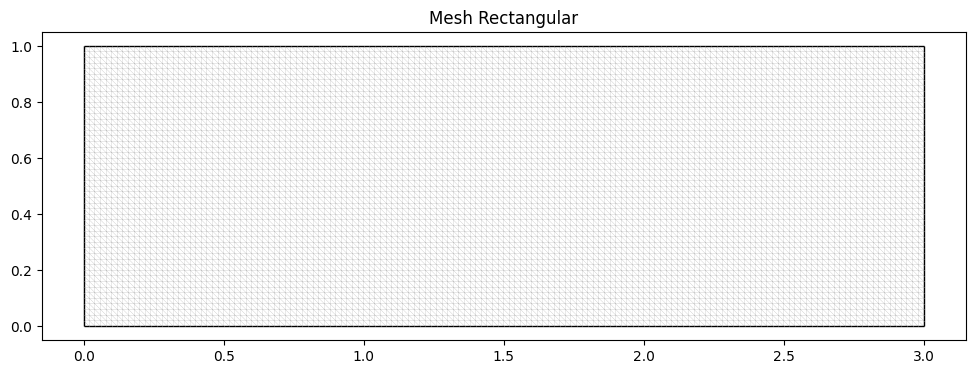

/usr/local/lib/python3.12/dist-packages/firedrake/_deprecation.py:65: UserWarning: The use of `File` for output is deprecated, please update your code to use `VTKFile` from `firedrake.output`.
  warn(



▼ Step 01 / 50 | Time: 0.20 s
  ├─ Cylinder Velocity -->   0.0472
  ├─ Drag Force --------->  -0.2249
  ├─ Lift Force --------->   0.0000
  ├─ Mean Velocity ------>   0.1212
  ├─ Bulk Reynolds Num -->   0.2417
  └─ Max Fluid Velocity ->   0.1839



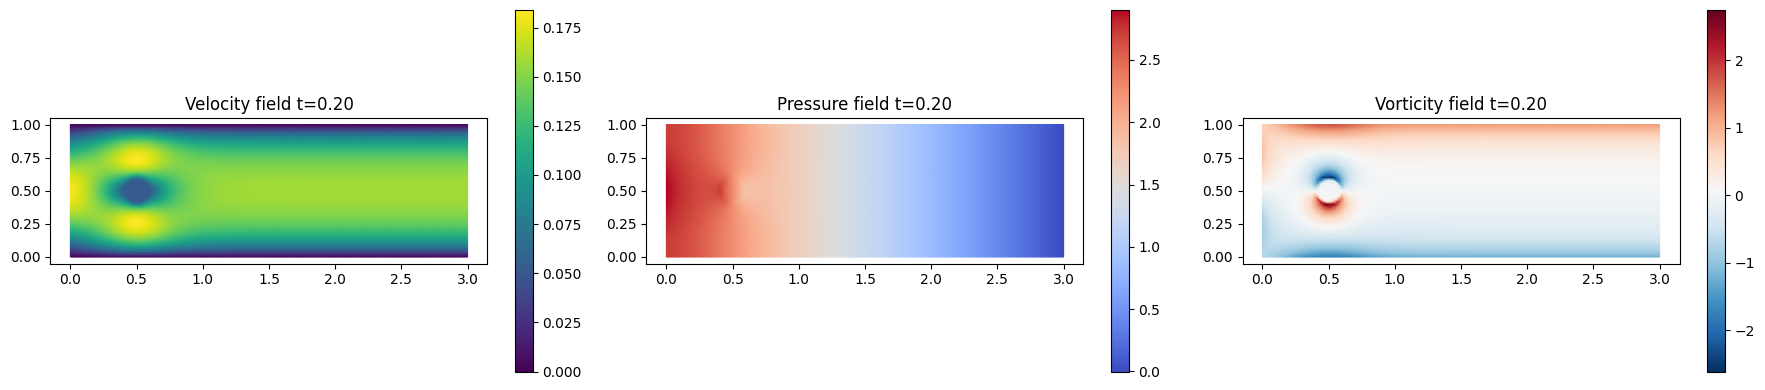


▼ Step 02 / 50 | Time: 0.40 s
  ├─ Cylinder Velocity -->   0.0938
  ├─ Drag Force --------->  -0.3592
  ├─ Lift Force --------->  -0.0006
  ├─ Mean Velocity ------>   0.2205
  ├─ Bulk Reynolds Num -->   0.4396
  └─ Max Fluid Velocity ->   0.3366


▼ Step 03 / 50 | Time: 0.60 s
  ├─ Cylinder Velocity -->   0.1388
  ├─ Drag Force --------->  -0.4619
  ├─ Lift Force --------->  -0.0052
  ├─ Mean Velocity ------>   0.3017
  ├─ Bulk Reynolds Num -->   0.6016
  └─ Max Fluid Velocity ->   0.4593


▼ Step 04 / 50 | Time: 0.80 s
  ├─ Cylinder Velocity -->   0.1816
  ├─ Drag Force --------->  -0.5232
  ├─ Lift Force --------->   0.0012
  ├─ Mean Velocity ------>   0.3682
  ├─ Bulk Reynolds Num -->   0.7342
  └─ Max Fluid Velocity ->   0.5578


▼ Step 05 / 50 | Time: 1.00 s
  ├─ Cylinder Velocity -->   0.2216
  ├─ Drag Force --------->  -0.5807
  ├─ Lift Force --------->   0.0047
  ├─ Mean Velocity ------>   0.4226
  ├─ Bulk Reynolds Num -->   0.8428
  └─ Max Fluid Velocity ->   0.6365


▼ Step 

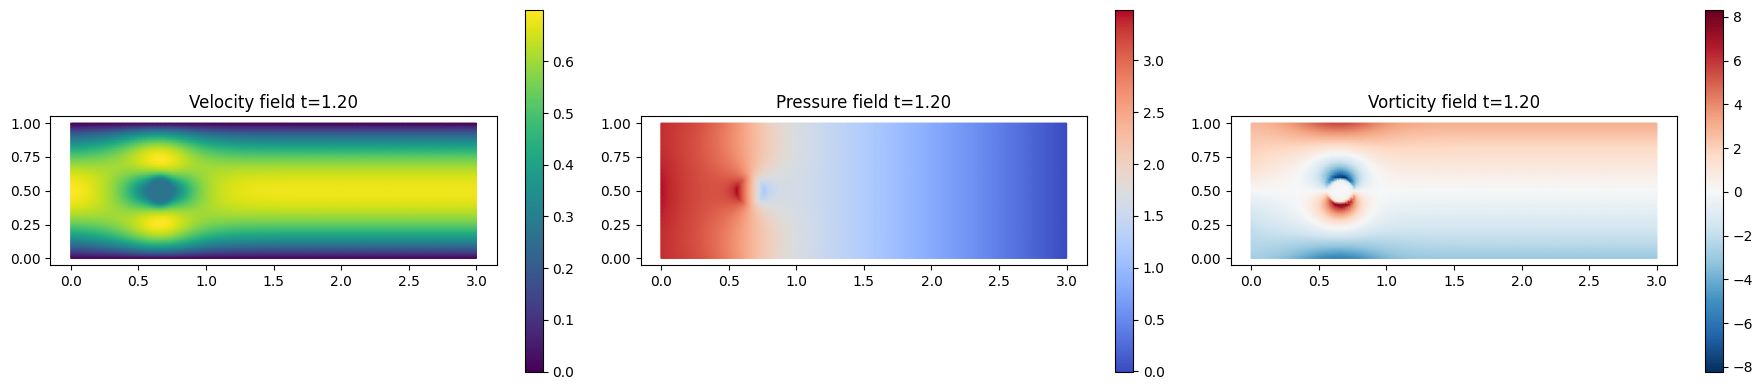


▼ Step 07 / 50 | Time: 1.40 s
  ├─ Cylinder Velocity -->   0.2905
  ├─ Drag Force --------->  -0.6583
  ├─ Lift Force --------->  -0.0064
  ├─ Mean Velocity ------>   0.5035
  ├─ Bulk Reynolds Num -->   1.0045
  └─ Max Fluid Velocity ->   0.7534


▼ Step 08 / 50 | Time: 1.60 s
  ├─ Cylinder Velocity -->   0.3183
  ├─ Drag Force --------->  -0.6908
  ├─ Lift Force --------->  -0.0070
  ├─ Mean Velocity ------>   0.5333
  ├─ Bulk Reynolds Num -->   1.0641
  └─ Max Fluid Velocity ->   0.7981


▼ Step 09 / 50 | Time: 1.80 s
  ├─ Cylinder Velocity -->   0.3411
  ├─ Drag Force --------->  -0.7137
  ├─ Lift Force --------->   0.0029
  ├─ Mean Velocity ------>   0.5577
  ├─ Bulk Reynolds Num -->   1.1129
  └─ Max Fluid Velocity ->   0.8347


▼ Step 10 / 50 | Time: 2.00 s
  ├─ Cylinder Velocity -->   0.3585
  ├─ Drag Force --------->  -0.7214
  ├─ Lift Force --------->   0.0055
  ├─ Mean Velocity ------>   0.5777
  ├─ Bulk Reynolds Num -->   1.1529
  └─ Max Fluid Velocity ->   0.8647


▼ Step 

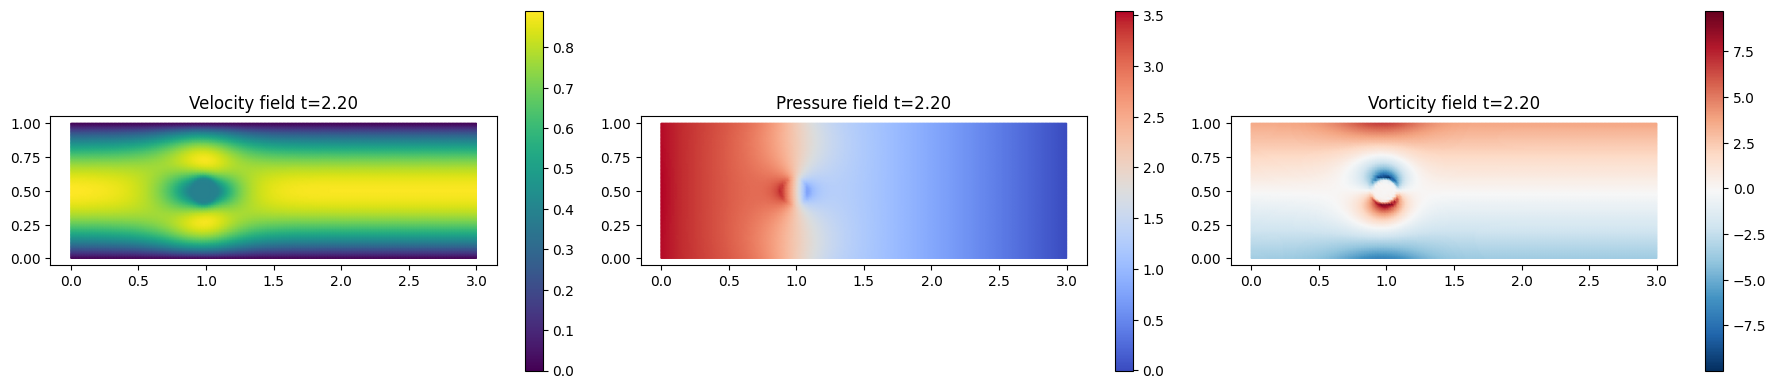


▼ Step 12 / 50 | Time: 2.40 s
  ├─ Cylinder Velocity -->   0.3762
  ├─ Drag Force --------->  -0.7715
  ├─ Lift Force --------->  -0.0077
  ├─ Mean Velocity ------>   0.6075
  ├─ Bulk Reynolds Num -->   1.2124
  └─ Max Fluid Velocity ->   0.9093


▼ Step 13 / 50 | Time: 2.60 s
  ├─ Cylinder Velocity -->   0.3762
  ├─ Drag Force --------->  -0.7987
  ├─ Lift Force --------->  -0.0065
  ├─ Mean Velocity ------>   0.6185
  ├─ Bulk Reynolds Num -->   1.2343
  └─ Max Fluid Velocity ->   0.9257


▼ Step 14 / 50 | Time: 2.80 s
  ├─ Cylinder Velocity -->   0.3703
  ├─ Drag Force --------->  -0.8257
  ├─ Lift Force --------->  -0.0043
  ├─ Mean Velocity ------>   0.6275
  ├─ Bulk Reynolds Num -->   1.2523
  └─ Max Fluid Velocity ->   0.9392


▼ Step 15 / 50 | Time: 3.00 s
  ├─ Cylinder Velocity -->   0.3585
  ├─ Drag Force --------->  -0.8561
  ├─ Lift Force --------->   0.0065
  ├─ Mean Velocity ------>   0.6350
  ├─ Bulk Reynolds Num -->   1.2670
  └─ Max Fluid Velocity ->   0.9527


▼ Step 

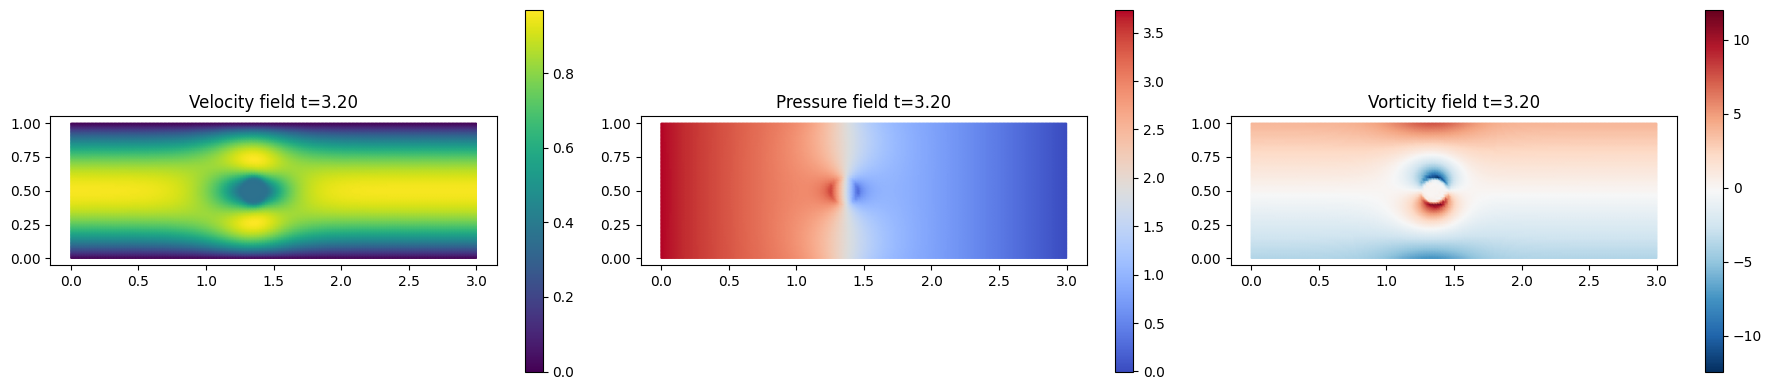


▼ Step 17 / 50 | Time: 3.40 s
  ├─ Cylinder Velocity -->   0.3183
  ├─ Drag Force --------->  -0.9608
  ├─ Lift Force --------->  -0.0120
  ├─ Mean Velocity ------>   0.6462
  ├─ Bulk Reynolds Num -->   1.2888
  └─ Max Fluid Velocity ->   0.9866


▼ Step 18 / 50 | Time: 3.60 s
  ├─ Cylinder Velocity -->   0.2905
  ├─ Drag Force --------->  -1.0001
  ├─ Lift Force --------->  -0.0125
  ├─ Mean Velocity ------>   0.6505
  ├─ Bulk Reynolds Num -->   1.2969
  └─ Max Fluid Velocity ->   1.0041


▼ Step 19 / 50 | Time: 3.80 s
  ├─ Cylinder Velocity -->   0.2581
  ├─ Drag Force --------->  -1.0584
  ├─ Lift Force --------->  -0.0067
  ├─ Mean Velocity ------>   0.6540
  ├─ Bulk Reynolds Num -->   1.3035
  └─ Max Fluid Velocity ->   1.0221


▼ Step 20 / 50 | Time: 4.00 s
  ├─ Cylinder Velocity -->   0.2216
  ├─ Drag Force --------->  -1.1001
  ├─ Lift Force --------->   0.0085
  ├─ Mean Velocity ------>   0.6570
  ├─ Bulk Reynolds Num -->   1.3089
  └─ Max Fluid Velocity ->   1.0409


▼ Step 

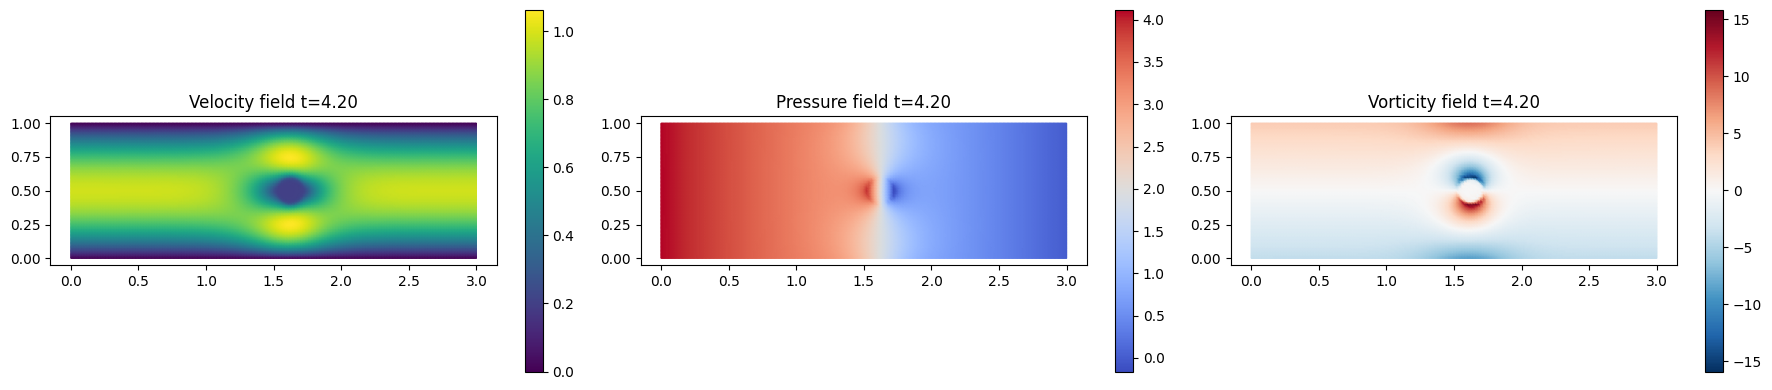


▼ Step 22 / 50 | Time: 4.40 s
  ├─ Cylinder Velocity -->   0.1388
  ├─ Drag Force --------->  -1.2465
  ├─ Lift Force --------->  -0.0134
  ├─ Mean Velocity ------>   0.6617
  ├─ Bulk Reynolds Num -->   1.3170
  └─ Max Fluid Velocity ->   1.0822


▼ Step 23 / 50 | Time: 4.60 s
  ├─ Cylinder Velocity -->   0.0938
  ├─ Drag Force --------->  -1.3036
  ├─ Lift Force --------->  -0.0034
  ├─ Mean Velocity ------>   0.6636
  ├─ Bulk Reynolds Num -->   1.3199
  └─ Max Fluid Velocity ->   1.1031


▼ Step 24 / 50 | Time: 4.80 s
  ├─ Cylinder Velocity -->   0.0472
  ├─ Drag Force --------->  -1.3717
  ├─ Lift Force --------->   0.0003
  ├─ Mean Velocity ------>   0.6653
  ├─ Bulk Reynolds Num -->   1.3224
  └─ Max Fluid Velocity ->   1.1246


▼ Step 25 / 50 | Time: 5.00 s
  ├─ Cylinder Velocity -->  -0.0000
  ├─ Drag Force --------->  -1.4274
  ├─ Lift Force --------->  -0.0123
  ├─ Mean Velocity ------>   0.6668
  ├─ Bulk Reynolds Num -->   1.3243
  └─ Max Fluid Velocity ->   1.1470


▼ Step 

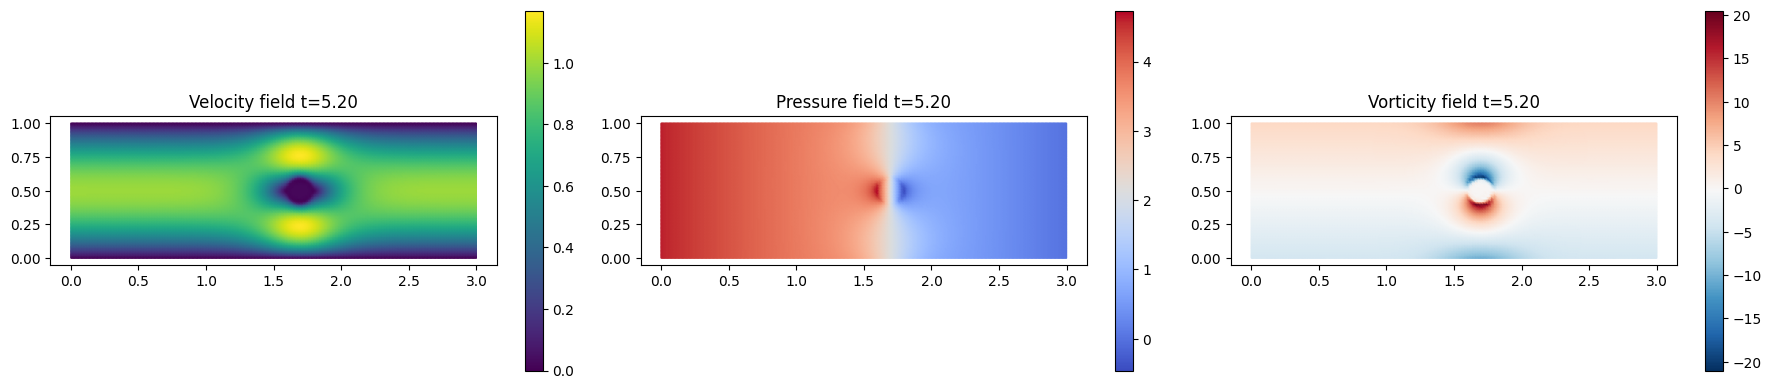


▼ Step 27 / 50 | Time: 5.40 s
  ├─ Cylinder Velocity -->  -0.0938
  ├─ Drag Force --------->  -1.5795
  ├─ Lift Force --------->  -0.0019
  ├─ Mean Velocity ------>   0.6705
  ├─ Bulk Reynolds Num -->   1.3273
  └─ Max Fluid Velocity ->   1.1906


▼ Step 28 / 50 | Time: 5.60 s
  ├─ Cylinder Velocity -->  -0.1388
  ├─ Drag Force --------->  -1.6608
  ├─ Lift Force --------->  -0.0195
  ├─ Mean Velocity ------>   0.6726
  ├─ Bulk Reynolds Num -->   1.3284
  └─ Max Fluid Velocity ->   1.2103


▼ Step 29 / 50 | Time: 5.80 s
  ├─ Cylinder Velocity -->  -0.1816
  ├─ Drag Force --------->  -1.6863
  ├─ Lift Force --------->   0.0037
  ├─ Mean Velocity ------>   0.6745
  ├─ Bulk Reynolds Num -->   1.3293
  └─ Max Fluid Velocity ->   1.2307


▼ Step 30 / 50 | Time: 6.00 s
  ├─ Cylinder Velocity -->  -0.2216
  ├─ Drag Force --------->  -1.7599
  ├─ Lift Force --------->   0.0144
  ├─ Mean Velocity ------>   0.6764
  ├─ Bulk Reynolds Num -->   1.3300
  └─ Max Fluid Velocity ->   1.2494


▼ Step 

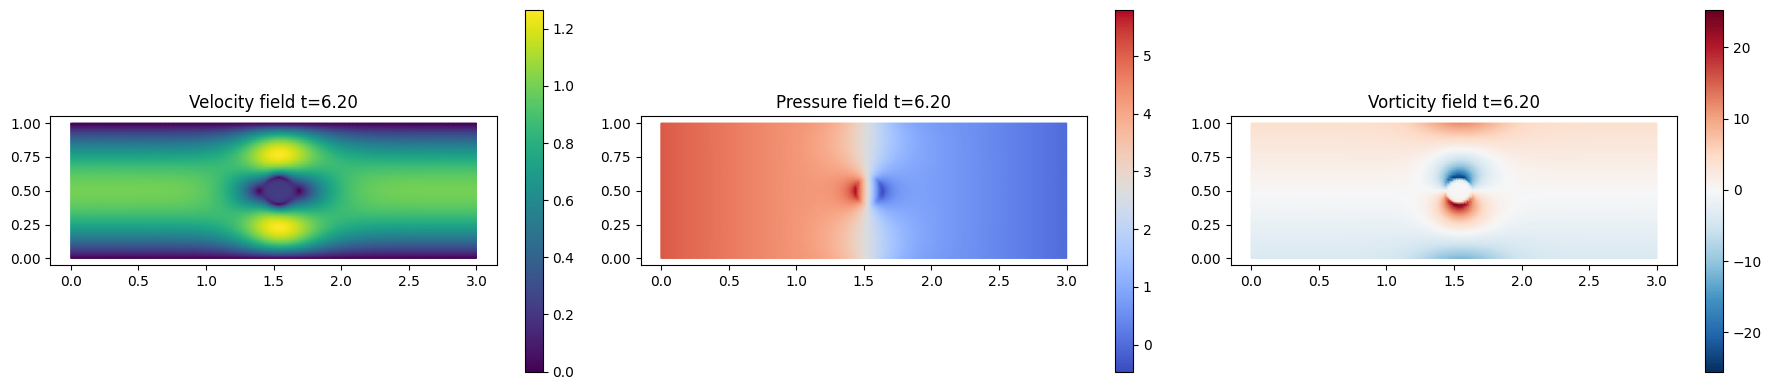


▼ Step 32 / 50 | Time: 6.40 s
  ├─ Cylinder Velocity -->  -0.2905
  ├─ Drag Force --------->  -1.8853
  ├─ Lift Force --------->  -0.0179
  ├─ Mean Velocity ------>   0.6797
  ├─ Bulk Reynolds Num -->   1.3311
  └─ Max Fluid Velocity ->   1.2805


▼ Step 33 / 50 | Time: 6.60 s
  ├─ Cylinder Velocity -->  -0.3183
  ├─ Drag Force --------->  -1.9519
  ├─ Lift Force --------->  -0.0195
  ├─ Mean Velocity ------>   0.6810
  ├─ Bulk Reynolds Num -->   1.3315
  └─ Max Fluid Velocity ->   1.2934


▼ Step 34 / 50 | Time: 6.80 s
  ├─ Cylinder Velocity -->  -0.3411
  ├─ Drag Force --------->  -1.9912
  ├─ Lift Force --------->   0.0078
  ├─ Mean Velocity ------>   0.6821
  ├─ Bulk Reynolds Num -->   1.3318
  └─ Max Fluid Velocity ->   1.3035


▼ Step 35 / 50 | Time: 7.00 s
  ├─ Cylinder Velocity -->  -0.3585
  ├─ Drag Force --------->  -1.9827
  ├─ Lift Force --------->   0.0145
  ├─ Mean Velocity ------>   0.6830
  ├─ Bulk Reynolds Num -->   1.3321
  └─ Max Fluid Velocity ->   1.3116


▼ Step 

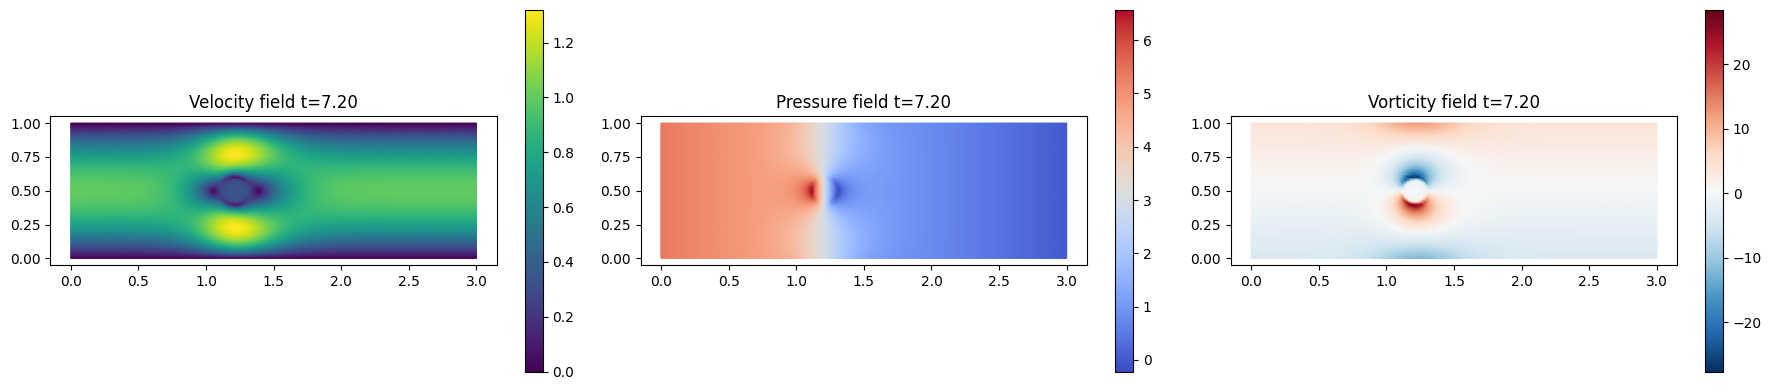


▼ Step 37 / 50 | Time: 7.40 s
  ├─ Cylinder Velocity -->  -0.3762
  ├─ Drag Force --------->  -2.0232
  ├─ Lift Force --------->  -0.0203
  ├─ Mean Velocity ------>   0.6840
  ├─ Bulk Reynolds Num -->   1.3325
  └─ Max Fluid Velocity ->   1.3197


▼ Step 38 / 50 | Time: 7.60 s
  ├─ Cylinder Velocity -->  -0.3762
  ├─ Drag Force --------->  -2.0224
  ├─ Lift Force --------->  -0.0162
  ├─ Mean Velocity ------>   0.6840
  ├─ Bulk Reynolds Num -->   1.3327
  └─ Max Fluid Velocity ->   1.3199


▼ Step 39 / 50 | Time: 7.80 s
  ├─ Cylinder Velocity -->  -0.3703
  ├─ Drag Force --------->  -2.0013
  ├─ Lift Force --------->  -0.0103
  ├─ Mean Velocity ------>   0.6839
  ├─ Bulk Reynolds Num -->   1.3328
  └─ Max Fluid Velocity ->   1.3187


▼ Step 40 / 50 | Time: 8.00 s
  ├─ Cylinder Velocity -->  -0.3585
  ├─ Drag Force --------->  -1.9672
  ├─ Lift Force --------->   0.0144
  ├─ Mean Velocity ------>   0.6834
  ├─ Bulk Reynolds Num -->   1.3329
  └─ Max Fluid Velocity ->   1.3130


▼ Step 

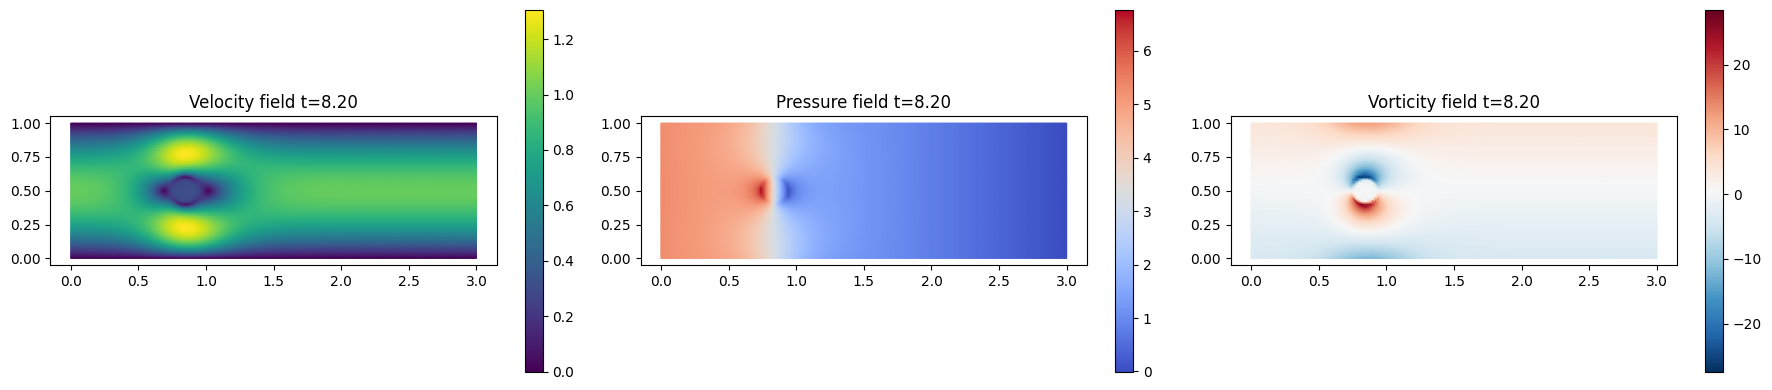


▼ Step 42 / 50 | Time: 8.40 s
  ├─ Cylinder Velocity -->  -0.3183
  ├─ Drag Force --------->  -1.9363
  ├─ Lift Force --------->  -0.0244
  ├─ Mean Velocity ------>   0.6818
  ├─ Bulk Reynolds Num -->   1.3330
  └─ Max Fluid Velocity ->   1.2956


▼ Step 43 / 50 | Time: 8.60 s
  ├─ Cylinder Velocity -->  -0.2905
  ├─ Drag Force --------->  -1.8646
  ├─ Lift Force --------->  -0.0237
  ├─ Mean Velocity ------>   0.6807
  ├─ Bulk Reynolds Num -->   1.3331
  └─ Max Fluid Velocity ->   1.2833


▼ Step 44 / 50 | Time: 8.80 s
  ├─ Cylinder Velocity -->  -0.2581
  ├─ Drag Force --------->  -1.8160
  ├─ Lift Force --------->  -0.0113
  ├─ Mean Velocity ------>   0.6795
  ├─ Bulk Reynolds Num -->   1.3331
  └─ Max Fluid Velocity ->   1.2693


▼ Step 45 / 50 | Time: 9.00 s
  ├─ Cylinder Velocity -->  -0.2216
  ├─ Drag Force --------->  -1.7284
  ├─ Lift Force --------->   0.0131
  ├─ Mean Velocity ------>   0.6782
  ├─ Bulk Reynolds Num -->   1.3332
  └─ Max Fluid Velocity ->   1.2534


▼ Step 

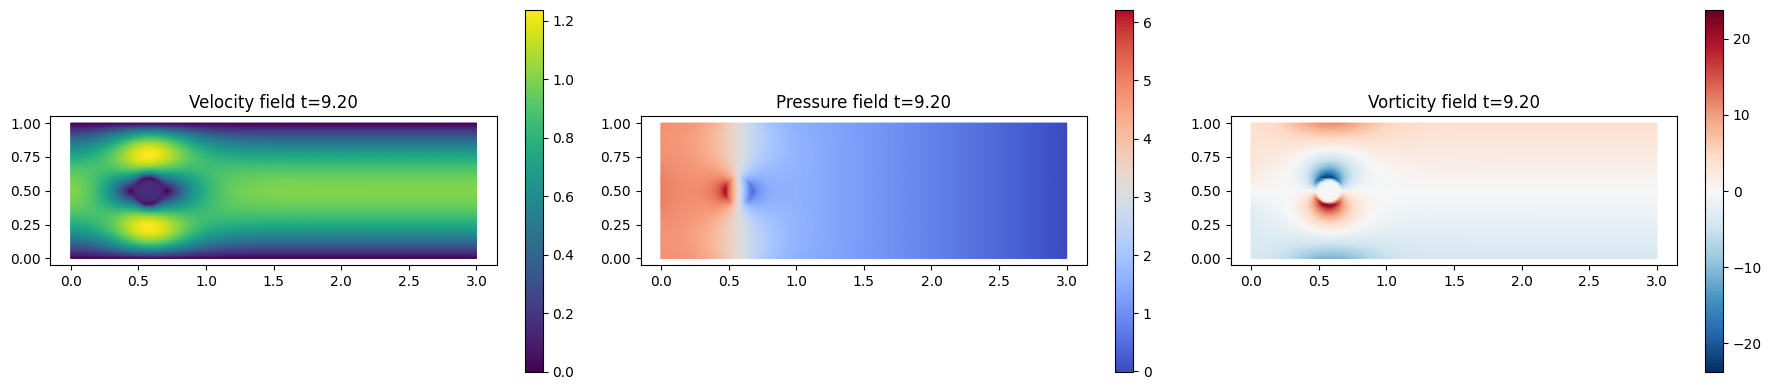


▼ Step 47 / 50 | Time: 9.40 s
  ├─ Cylinder Velocity -->  -0.1388
  ├─ Drag Force --------->  -1.6279
  ├─ Lift Force --------->  -0.0178
  ├─ Mean Velocity ------>   0.6753
  ├─ Bulk Reynolds Num -->   1.3332
  └─ Max Fluid Velocity ->   1.2170


▼ Step 48 / 50 | Time: 9.60 s
  ├─ Cylinder Velocity -->  -0.0938
  ├─ Drag Force --------->  -1.5474
  ├─ Lift Force --------->  -0.0048
  ├─ Mean Velocity ------>   0.6739
  ├─ Bulk Reynolds Num -->   1.3332
  └─ Max Fluid Velocity ->   1.1967


▼ Step 49 / 50 | Time: 9.80 s
  ├─ Cylinder Velocity -->  -0.0472
  ├─ Drag Force --------->  -1.4776
  ├─ Lift Force --------->   0.0001
  ├─ Mean Velocity ------>   0.6726
  ├─ Bulk Reynolds Num -->   1.3333
  └─ Max Fluid Velocity ->   1.1765


▼ Step 50 / 50 | Time: 10.00 s
  ├─ Cylinder Velocity -->  -0.0000
  ├─ Drag Force --------->  -1.3941
  ├─ Lift Force --------->  -0.0122
  ├─ Mean Velocity ------>   0.6718
  ├─ Bulk Reynolds Num -->   1.3333
  └─ Max Fluid Velocity ->   1.1563



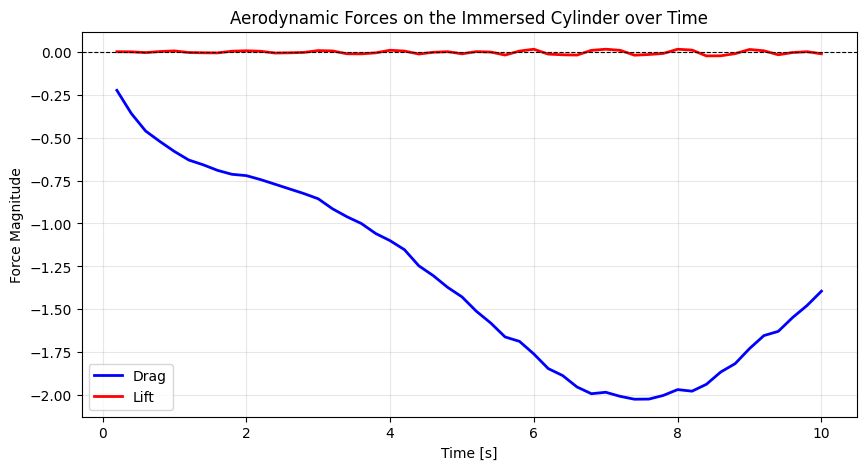

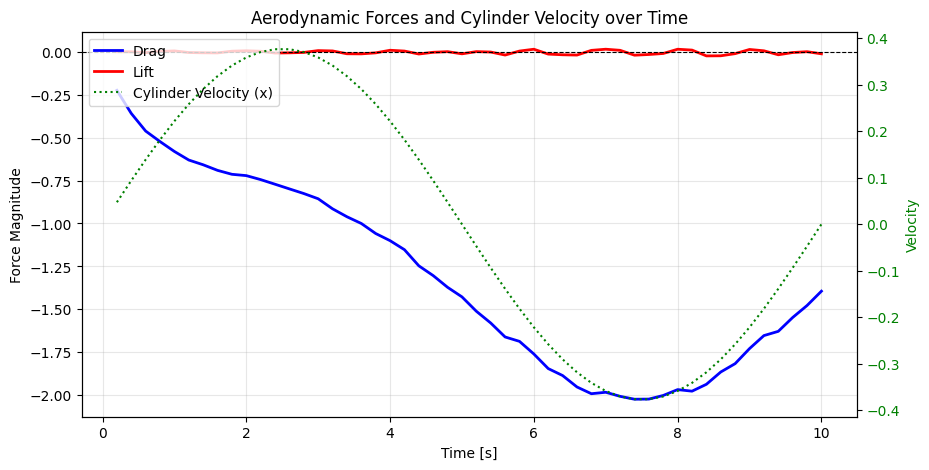

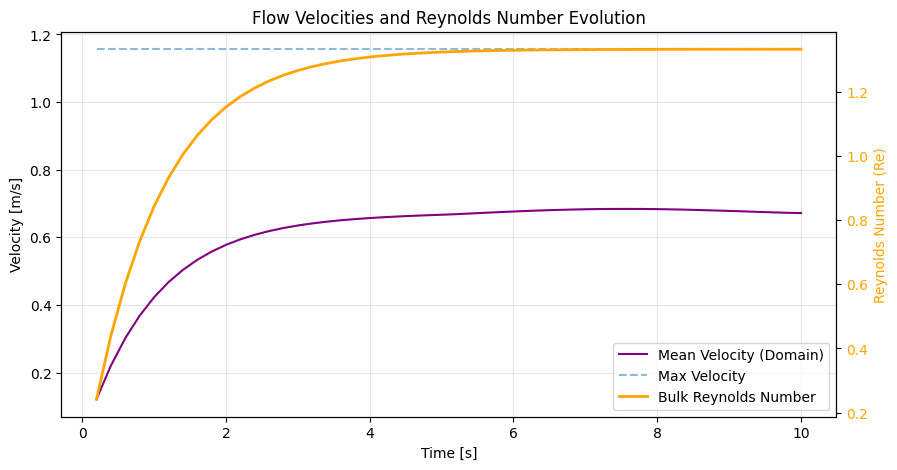

In [ ]:
from firedrake import *
import numpy as np
import os

import gmsh
from firedrake import Mesh

import matplotlib.pyplot as plt
from firedrake.plot import triplot

# ------- CONFIGURATION ------- #
CONFORMING = False  # if True, switch off Brinkman term (R=0) and create mesh conforming to obstacle
MOVING = True       # if True, the immersed obstacle is moving (see obstacles.py)

# To save all the results of the simulation
# def saveXDMF(file_dict, t, uh, ph, phi, chi, vort=None):
#     uh.rename("Velocity", "u")
#     ph.rename("Pressure", "p")
#     phi.rename("levelset", "phi")
#     chi.rename("characteristic", "chi")

#     file_dict['u'].write(uh, time=t)
#     file_dict['p'].write(ph, time=t)
#     file_dict['phi'].write(phi, time=t)
#     file_dict['chi'].write(chi, time=t)

def savePVD(file_dict, t, uh, ph, phi, chi, vort=None):
    uh.rename("Velocity")
    ph.rename("Pressure")

    file_dict['u'].write(uh, time=t)
    file_dict['p'].write(ph, time=t)
    file_dict['phi'].write(phi, time=t)
    file_dict['chi'].write(chi, time=t)
    if vort:
        vort.rename("Vorticity")
        file_dict['vort'].write(vort, time=t)

# ------- PARAMETERS ------- #
Lx, Ly = 3.0, 1.0
y_obs, r_obs = 0.5, 0.1
n_elements = 50

# ------- MESH ------- #
# ID Borders: 1: bottom, 2: top, 3: left, 4: right

def generate_conforming_mesh(Lx, Ly, x_obs, y_obs, r_obs, n):
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    model = gmsh.model
    model.add("Cylinder")

    # Resolution
    res = Ly / n

    # Geometry
    channel = model.occ.addRectangle(0, 0, 0, Lx, Ly)
    cylinder = model.occ.addDisk(x_obs, y_obs, 0, r_obs, r_obs)

    # Subtraction (Fluid = Channel - Cylinder)
    fluid_shape, _ = model.occ.cut([(2, channel)], [(2, cylinder)])
    model.occ.synchronize()

    # --- TAGGING ---
    # Fluid surface
    model.addPhysicalGroup(2, [fluid_shape[0][1]], name="Fluid")

    # Borders (Lines)
    lines = model.getEntities(1)
    for line in lines:
        mass_center = model.occ.getCenterOfMass(line[0], line[1])
        # x=0: Inflow, x=Lx: Outflow, y=0: Bottom, y=Ly: Top, else: Cylinder
        if np.isclose(mass_center[0], 0): model.addPhysicalGroup(1, [line[1]], 3)    # Inflow
        elif np.isclose(mass_center[0], Lx): model.addPhysicalGroup(1, [line[1]], 4) # Outflow
        elif np.isclose(mass_center[1], 0): model.addPhysicalGroup(1, [line[1]], 1)  # Bottom
        elif np.isclose(mass_center[1], Ly): model.addPhysicalGroup(1, [line[1]], 2) # Top
        else: model.addPhysicalGroup(1, [line[1]], 5)                                # Cylinder Boundary

    model.mesh.setSize(model.getEntities(0), res)
    model.mesh.generate(2)

    m = Mesh(model)
    gmsh.finalize()
    return m

if not CONFORMING:
  # RectangleMesh(nx, ny, Lx, Ly) nx : ny = 3 : 1 to keep the proportions
  mesh = RectangleMesh(n_elements * 3, n_elements, Lx, Ly)
else:
  mesh = generate_conforming_mesh(Lx, Ly, y_obs, y_obs, r_obs, n_elements)

# Define the coordinates of the mesh
x, y = SpatialCoordinate(mesh)

# Plot of the mesh
fig, axes = plt.subplots(figsize=(12, 4))
triplot(mesh, axes=axes,
        interior_kw={'linewidth': 0.1, 'alpha': 0.3},
        boundary_kw={'linewidth': 1.0, 'color': 'black'})
axes.set_aspect('equal')
axes.set_title(f"Mesh {'Conforming' if CONFORMING else 'Rectangular'}")
plt.show()

# ------- DATA ------- #
T = 10.0           # Time interval for the observed phenomenon
num_steps = 50     # Number of sub-intervals
dt = T / num_steps # Time discretization
# Parameters
mu = 0.1
rho = 1.0

# Definition of the radius depending on the chosen method
if CONFORMING:
    R = Constant(0)
else:
    R = Constant(n_elements * 20)

# Source and Inflow
t_param = Constant(0.0)
f = Constant((0.0, 0.0)) # Source --> Volume forces
# Parabolic profile: 4 * y * (1 - y) --> Poiseuille Profile
# Temporal Decay: 1.0 - e^(-t) --> To allow for a smooth acceleration
inflow_profile = as_vector([(1.0 - exp(-t_param)) * 4.0 * y * (1.0 - y), 0.0])

# ------- FUNCTIONAL SPACES ------- #
V = VectorFunctionSpace(mesh, "CG", 2)
Q = FunctionSpace(mesh, "CG", 1)
W = V * Q  # Mixed Space

# Function for the solution
sol = Function(W)
uh, ph = sol.subfunctions  # Subfunctions for direct access
uh_n = Function(V)         # Velocity at the previous step

# Space for vorticity
V_vort = FunctionSpace(mesh, "CG", 1)
vorticity = Function(V_vort, name="vorticity")

# ------- BOUNDARY CONDITIONS ------- #

if CONFORMING:
    # Convenzione Gmsh
    tag_inflow = 3
    tag_bottom = 1
    tag_top = 2
    tag_cylinder = 5
else:
    tag_inflow = 1
    tag_bottom = 3
    tag_top = 4
    tag_outflow = 2

bcs = [DirichletBC(W.sub(0), inflow_profile, tag_inflow), # Inflow (sinistra)
    DirichletBC(W.sub(0), Constant((0, 0)), tag_bottom),  # Bottom Wall
    DirichletBC(W.sub(0), Constant((0, 0)), tag_top)]     # Top Wall

if CONFORMING:
    # Add the boundary of the cylinder
    # It it is not moving it is Constant((0,0))
    bcs.append(DirichletBC(W.sub(0), Constant((0, 0)), tag_cylinder))

# ------- VARIATIONAL FORMULATION ------- #
u, p = TrialFunctions(W) # Trial functions
v, q = TestFunctions(W) # Test functions

# Define the obstacle
obstacle = circleObstacle(mesh, t_param, y_obs, y_obs, r_obs)

phi_expr = obstacle.distExpr() # Distance function (SDF)
chi_expr = obstacle.chi() # Characteristic Function
us_expr = as_vector([obstacle.us_x, obstacle.us_y]) # Obstacle velocity


# Brinkman Term: R * (u - us) * chi
# Weak Formulation:

# 1. Bilinear Form a((u.p), (v,q))
a = ( (rho / dt) * inner(u, v) * dx            # Inertia
    + mu * inner(grad(u), grad(v)) * dx        # Viscosity
    - div(v) * p * dx                          # Pressure
    + div(u) * q * dx                          # Incomprimibility
    + R * chi_expr * inner(u, v) * dx )        # Penalty term (flow part)

# 2. The right hand side L(v,q)
L = ( (rho / dt) * inner(uh_n, v) * dx          # Previous velocity
    + inner(f, v) * dx                          # External Forces
    + R * chi_expr * inner(us_expr, v) * dx )   # Penalty Term (obstacle/source part)



# ------- SETUP OUTPUT ------- #

# Dynamic definition of the path
dir1 = 'conforming' if CONFORMING else 'brinkman'
dir2 = 'moving' if MOVING else 'steady'
R_val = R.values()[0] if not CONFORMING else 0
basedir = f"cyl/{dir1}/{dir2}/n{n_elements}_R{R_val}/"
if not os.path.exists(basedir):
    os.makedirs(basedir)

# Create XDMF files for visualization output
file_u = File(basedir + "velocity.pvd")
file_p = File(basedir + "pressure.pvd")
file_phi = File(basedir + "phi.pvd")
file_chi = File(basedir + "chi.pvd")

file_vort = File(basedir + "vorticity.pvd")

file_dict = {'u': file_u, 'p': file_p, 'phi': file_phi, 'chi': file_chi}

with CheckpointFile(basedir + "mesh_checkpoint.h5", 'w') as f:
    f.save_mesh(mesh)

# Functions for visualization of the results
V_dg = FunctionSpace(mesh, "DG", 1)
phi_plot = Function(V_dg)
chi_plot = Function(V_dg)

# ------- TIME STEPPING ------- #
t = 0.0
uh_n.assign(0.0)

phi_plot.interpolate(phi_expr)
chi_plot.interpolate(chi_expr)

times = []
drags = []
lifts = []
us_x_history = [] # History of the velocity of th obstacle

# The following variables are used to compute the Reynolds number and the mean velocity
D_cyl = 2 * r_obs # Characteristic Diameter
domain_area = Lx * Ly # Area of the whole domain

u_mean_history = []
Re_history = []

savePVD(file_dict, 0.0, uh, ph, phi_plot, chi_plot)

# print(f"\n{'Step':>6} | {'Time':>6} | {'U_cyl_x':>10} | {'Drag':>10} | {'Lift':>10} | {'Max U':>10}")
# print("-" * 70)

for n in range(num_steps):
    t += dt
    t_param.assign(t) # Update the time in the expressions

    current_us_x = float(assemble(obstacle.us_x * dx(domain=mesh)) / assemble(Constant(1.0) * dx(domain=mesh)))

    if CONFORMING and MOVING:
        # Recover the space of the coordinates
        V_coord = mesh.coordinates.function_space()

        # Define the displacement
        v_x = float(obstacle.us_x) if not hasattr(obstacle.us_x, 'assign') else obstacle.us_x
        v_y = float(obstacle.us_y) if not hasattr(obstacle.us_y, 'assign') else obstacle.us_y

        # Rigid displacement of the whole mesh
        displacement = interpolate(as_vector([velocity_x * dt, velocity_y * dt]), V_coord)
        mesh.coordinates.assign(mesh.coordinates + displacement)

    # Solve the Linear System
    solve(a == L, sol, bcs=bcs,
          solver_parameters={
              "ksp_type": "gmres",
              "pc_type": "lu",
              "pc_factor_mat_solver_type": "mumps"
          })

    # Compute Vorticity: rot(u) = dv/dx - du/dy
    vort_expr = uh[1].dx(0) - uh[0].dx(1)
    vorticity.project(vort_expr)

    # Compute Drag and Lift (Brinkman Force acting on the fluid)
    # F = integral( R * chi * (u_s - u) )
    drag = assemble(R * chi_expr * (us_expr[0] - uh[0]) * dx)
    lift = assemble(R * chi_expr * (us_expr[1] - uh[1]) * dx)

    times.append(t)
    drags.append(drag)
    lifts.append(lift)
    us_x_history.append(current_us_x)

    # print(f"Time {t:.2f} | Drag: {drag:10.4f} | Lift: {lift:10.4f}")
    # print(f"Step {n+1}/{num_steps} - Time: {t:.2f}")
    # max_u = uh.vector().norm("inf")

    # Max Velocity
    max_u = np.max(np.abs(uh.dat.data_ro))

    # Mean Velocity
    u_mean = assemble(sqrt(inner(uh, uh)) * dx) / domain_area

    # Bulk velocity
    u_bulk = float(assemble(uh[0] * ds(tag_inflow)) / Ly)
    # Bulk Reynolds Number: Re = (rho * U * D) / mu
    Re = (rho * u_bulk * D_cyl) / mu

    u_mean_history.append(u_mean)
    Re_history.append(Re)

    print()
    print(f"▼ Step {n+1:02d} / {num_steps} | Time: {t:4.2f} s")
    print(f"  ├─ Cylinder Velocity --> {current_us_x:8.4f}")
    print(f"  ├─ Drag Force ---------> {drag:8.4f}")
    print(f"  ├─ Lift Force ---------> {lift:8.4f}")
    print(f"  ├─ Mean Velocity ------> {u_mean:8.4f}")
    print(f"  ├─ Bulk Reynolds Num --> {Re:8.4f}")
    print(f"  └─ Max Fluid Velocity -> {max_u:8.4f}")
    print()

    if n % 5 == 0:

        fig, axs = plt.subplots(1, 3, figsize=(18, 4))

        # Velocity field plot
        col1 = tripcolor(uh, axes=axs[0], cmap="viridis")
        axs[0].set_title(f"Velocity field t={t:.2f}")
        axs[0].set_aspect('equal')
        fig.colorbar(col1, ax=axs[0])

        # Pressure field plot
        col2 = tripcolor(ph, axes=axs[1], cmap="coolwarm")
        axs[1].set_title(f"Pressure field t={t:.2f}")
        axs[1].set_aspect('equal')
        fig.colorbar(col2, ax=axs[1])

        # Vorticity field plot
        col3 = tripcolor(vorticity, axes=axs[2], cmap="RdBu_r")
        axs[2].set_title(f"Vorticity field t={t:.2f}")
        axs[2].set_aspect('equal')
        fig.colorbar(col3, ax=axs[2])

        plt.tight_layout()
        plt.show()

    # Update uh_n for the next step
    uh_n.assign(sol.subfunctions[0])

    # Output data
    phi_plot.interpolate(phi_expr)
    chi_plot.interpolate(chi_expr)
    savePVD(file_dict, t, uh, ph, phi_plot, chi_plot)

# ------- FINAL FORCES PLOT ------- #

# 1. Just the forces
plt.figure(figsize=(10, 5))
plt.plot(times, drags, label='Drag', color='blue', linewidth=2)
plt.plot(times, lifts, label='Lift', color='red', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Force Magnitude')
plt.title('Aerodynamic Forces on the Immersed Cylinder over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Forces and Cylinder velocity
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(times, drags, label='Drag', color='blue', linewidth=2)
ax1.plot(times, lifts, label='Lift', color='red', linewidth=2)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Force Magnitude')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(times, us_x_history, label='Cylinder Velocity (x)', color='green', linewidth=1.5, linestyle=':')
ax2.set_ylabel('Velocity', color='green')
ax2.tick_params(axis='y', labelcolor='green')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Aerodynamic Forces and Cylinder Velocity over Time')
plt.show()

# ------- PLOT: REYNOLDS and MEAN VELOCITY ------- #
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(times, u_mean_history, label='Mean Velocity (Domain)', color='purple')
ax1.plot(times, [np.max(np.abs(uh.dat.data_ro))]*len(times), '--', label='Max Velocity', alpha=0.5)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Velocity [m/s]')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(times, Re_history, label='Bulk Reynolds Number', color='orange', linewidth=2)
ax2.set_ylabel('Reynolds Number (Re)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')

plt.title('Flow Velocities and Reynolds Number Evolution')
plt.show()




--- STROUHAL NUMBER ANALYSIS ---
Detachment frequency (f)  : 1.0000 Hz
Mean Period (T)           : 1.0000 s
Regime Bulk Velocity      : 0.6666 m/s
Strouhal Number (St)      : 0.3000


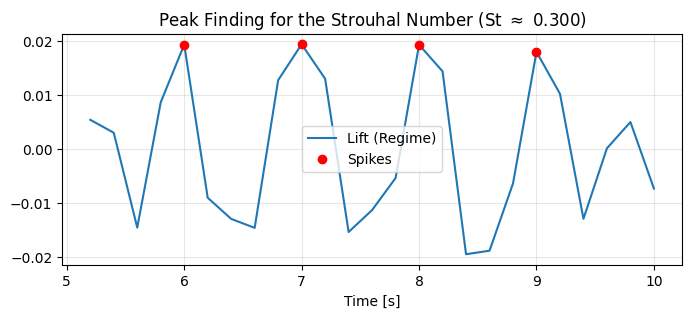

In [ ]:
from scipy.signal import find_peaks

# Cut the transitory
cut_idx = len(times) // 2
t_regime = np.array(times[cut_idx:])
lift_regime = np.array(lifts[cut_idx:])

# Remove the mean lift
lift_centered = lift_regime - np.mean(lift_regime)

# Search spikes
peaks, _ = find_peaks(lift_centered, distance=5)

print("\n--- STROUHAL NUMBER ANALYSIS ---")

if len(peaks) >= 2:
    # Compute the mean interval between the spikes
    peak_times = t_regime[peaks]
    T_shedding = np.mean(np.diff(peak_times))
    f_st = 1.0 / T_shedding

    # Regime U_bulk
    # Re = (rho * U * D) / mu  =>  U = (Re * mu) / (rho * D)
    u_bulk_final = (Re_history[-1] * mu) / (rho * D_cyl)

    # Compute Strouhal number
    St = (f_st * D_cyl) / u_bulk_final

    print(f"Detachment frequency (f)  : {f_st:.4f} Hz")
    print(f"Mean Period (T)           : {T_shedding:.4f} s")
    print(f"Regime Bulk Velocity      : {u_bulk_final:.4f} m/s")
    print(f"Strouhal Number (St)      : {St:.4f}")

    plt.figure(figsize=(8, 3))
    plt.plot(t_regime, lift_centered, label='Lift (Regime)')
    plt.plot(t_regime[peaks], lift_centered[peaks], 'ro', label='Spikes')
    plt.title(f"Peak Finding for the Strouhal Number (St $\\approx$ {St:.3f})")
    plt.xlabel("Time [s]")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("WARNING: Not enough spikes to compute the frequency.")

# **RIIS (Immersed surface)**

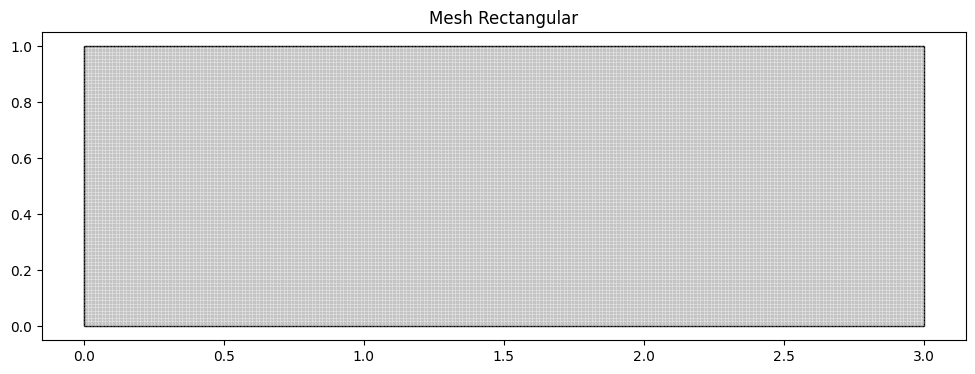

/usr/local/lib/python3.12/dist-packages/firedrake/_deprecation.py:65: UserWarning: The use of `File` for output is deprecated, please update your code to use `VTKFile` from `firedrake.output`.
  warn(



▼ Step 01 / 20 | Time: 0.05 s
  ├─ Obstacle Velocity -->   0.3812
  ├─ Drag Force --------->   3.7517
  ├─ Lift Force --------->  -0.0804
  ├─ Mean Velocity ------>   0.0658
  ├─ Bulk Reynolds Num -->   0.0650
  └─ Max Fluid Velocity ->   0.4020



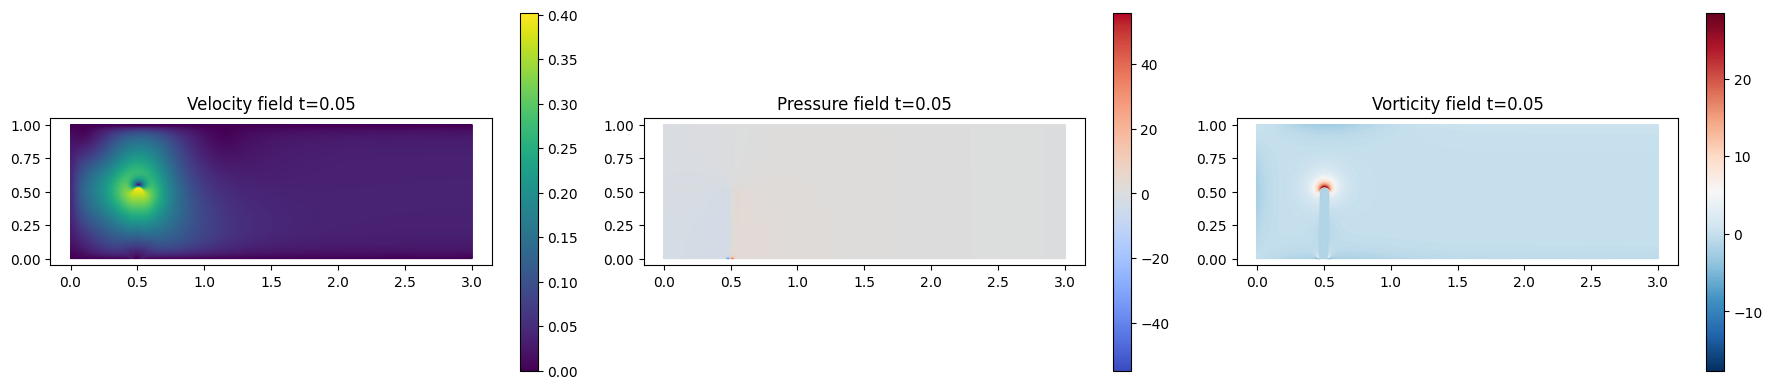


▼ Step 02 / 20 | Time: 0.10 s
  ├─ Obstacle Velocity -->   0.7252
  ├─ Drag Force --------->   4.5788
  ├─ Lift Force --------->  -0.6696
  ├─ Mean Velocity ------>   0.1299
  ├─ Bulk Reynolds Num -->   0.1269
  └─ Max Fluid Velocity ->   0.7634


▼ Step 03 / 20 | Time: 0.15 s
  ├─ Obstacle Velocity -->   0.9981
  ├─ Drag Force --------->   4.7443
  ├─ Lift Force --------->  -1.8718
  ├─ Mean Velocity ------>   0.1866
  ├─ Bulk Reynolds Num -->   0.1857
  └─ Max Fluid Velocity ->   1.0412


▼ Step 04 / 20 | Time: 0.20 s
  ├─ Obstacle Velocity -->   1.1733
  ├─ Drag Force --------->   4.3249
  ├─ Lift Force --------->  -3.5859
  ├─ Mean Velocity ------>   0.2314
  ├─ Bulk Reynolds Num -->   0.2417
  └─ Max Fluid Velocity ->   1.1986


▼ Step 05 / 20 | Time: 0.25 s
  ├─ Obstacle Velocity -->   1.2337
  ├─ Drag Force --------->   3.4055
  ├─ Lift Force --------->  -5.5858
  ├─ Mean Velocity ------>   0.2607
  ├─ Bulk Reynolds Num -->   0.2949
  └─ Max Fluid Velocity ->   1.2126


▼ Step 

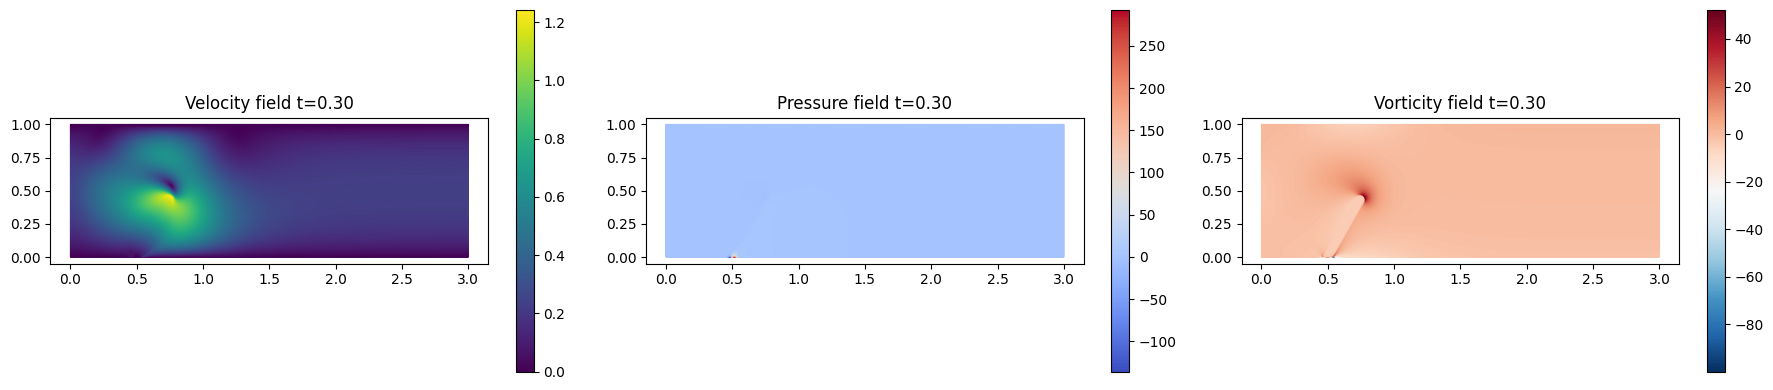


▼ Step 07 / 20 | Time: 0.35 s
  ├─ Obstacle Velocity -->   0.9981
  ├─ Drag Force --------->   0.7467
  ├─ Lift Force --------->  -8.5260
  ├─ Mean Velocity ------>   0.2682
  ├─ Bulk Reynolds Num -->   0.3937
  └─ Max Fluid Velocity ->   0.9150


▼ Step 08 / 20 | Time: 0.40 s
  ├─ Obstacle Velocity -->   0.7252
  ├─ Drag Force --------->  -0.6741
  ├─ Lift Force --------->  -7.5353
  ├─ Mean Velocity ------>   0.2541
  ├─ Bulk Reynolds Num -->   0.4396
  └─ Max Fluid Velocity ->   0.7607


▼ Step 09 / 20 | Time: 0.45 s
  ├─ Obstacle Velocity -->   0.3812
  ├─ Drag Force --------->  -2.0849
  ├─ Lift Force --------->  -3.4902
  ├─ Mean Velocity ------>   0.2468
  ├─ Bulk Reynolds Num -->   0.4832
  └─ Max Fluid Velocity ->   0.7193


▼ Step 10 / 20 | Time: 0.50 s
  ├─ Obstacle Velocity -->   0.0000
  ├─ Drag Force --------->  -3.4657
  ├─ Lift Force --------->   2.9183
  ├─ Mean Velocity ------>   0.2661
  ├─ Bulk Reynolds Num -->   0.5246
  └─ Max Fluid Velocity ->   0.8474


▼ Step 

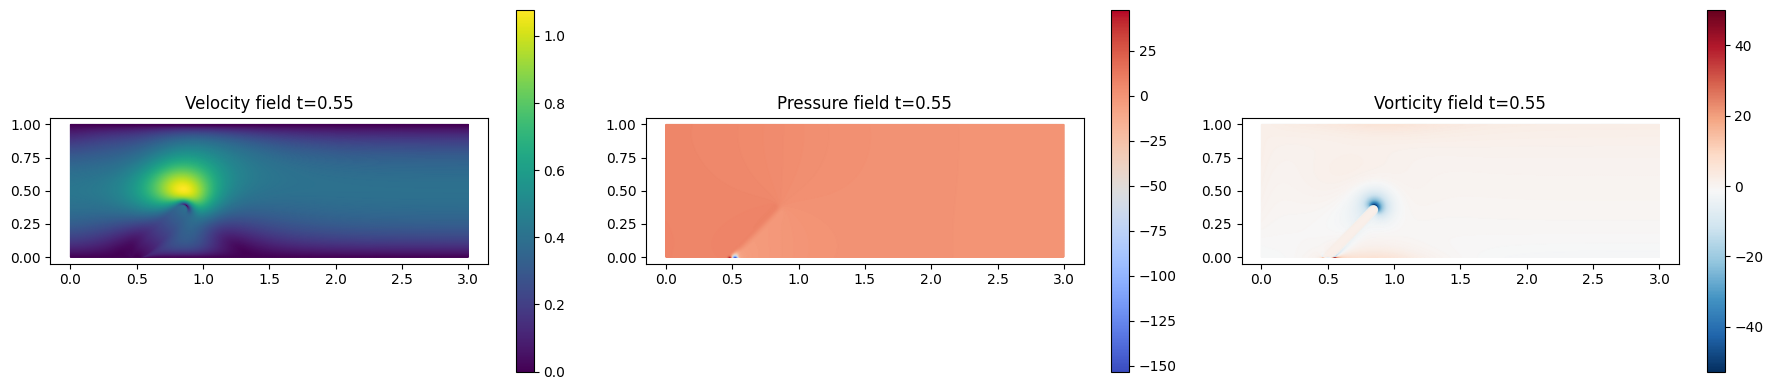


▼ Step 12 / 20 | Time: 0.60 s
  ├─ Obstacle Velocity -->  -0.7252
  ├─ Drag Force --------->  -5.8318
  ├─ Lift Force --------->  11.6823
  ├─ Mean Velocity ------>   0.3871
  ├─ Bulk Reynolds Num -->   0.6016
  └─ Max Fluid Velocity ->   1.3458


▼ Step 13 / 20 | Time: 0.65 s
  ├─ Obstacle Velocity -->  -0.9981
  ├─ Drag Force --------->  -6.6753
  ├─ Lift Force --------->  11.1104
  ├─ Mean Velocity ------>   0.4482
  ├─ Bulk Reynolds Num -->   0.6373
  └─ Max Fluid Velocity ->   1.6250


▼ Step 14 / 20 | Time: 0.70 s
  ├─ Obstacle Velocity -->  -1.1733
  ├─ Drag Force --------->  -7.1870
  ├─ Lift Force --------->   8.5345
  ├─ Mean Velocity ------>   0.4985
  ├─ Bulk Reynolds Num -->   0.6712
  └─ Max Fluid Velocity ->   1.8834


▼ Step 15 / 20 | Time: 0.75 s
  ├─ Obstacle Velocity -->  -1.2337
  ├─ Drag Force --------->  -7.1938
  ├─ Lift Force --------->   5.4112
  ├─ Mean Velocity ------>   0.5327
  ├─ Bulk Reynolds Num -->   0.7035
  └─ Max Fluid Velocity ->   2.0793


▼ Step 

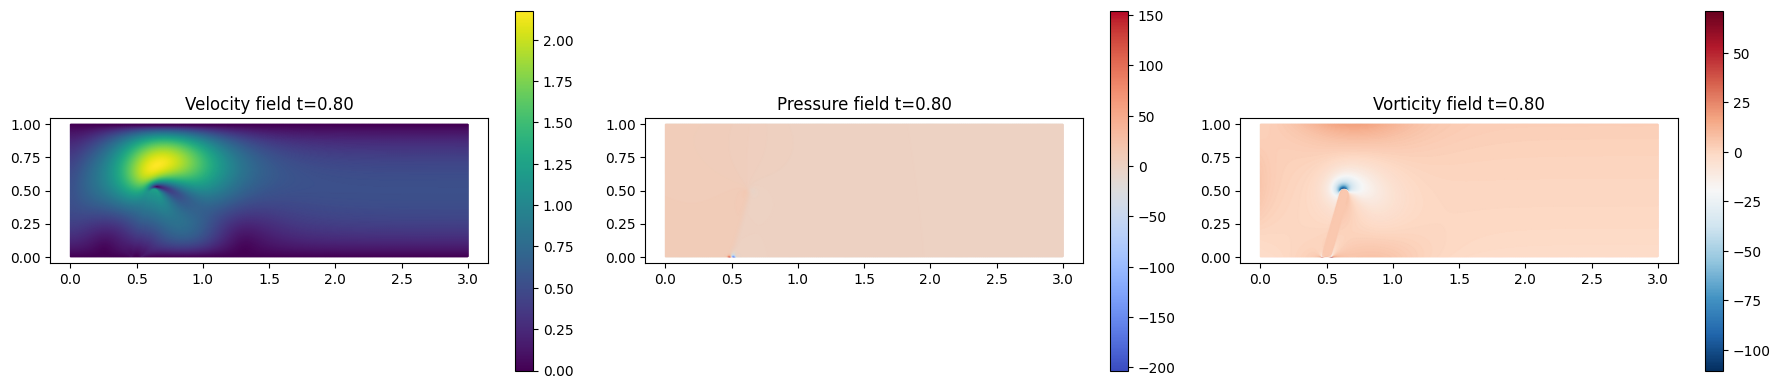


▼ Step 17 / 20 | Time: 0.85 s
  ├─ Obstacle Velocity -->  -0.9981
  ├─ Drag Force --------->  -5.0866
  ├─ Lift Force --------->   0.6875
  ├─ Mean Velocity ------>   0.5421
  ├─ Bulk Reynolds Num -->   0.7634
  └─ Max Fluid Velocity ->   2.1295


▼ Step 18 / 20 | Time: 0.90 s
  ├─ Obstacle Velocity -->  -0.7252
  ├─ Drag Force --------->  -3.1425
  ├─ Lift Force --------->  -0.3286
  ├─ Mean Velocity ------>   0.5193
  ├─ Bulk Reynolds Num -->   0.7912
  └─ Max Fluid Velocity ->   1.9649


▼ Step 19 / 20 | Time: 0.95 s
  ├─ Obstacle Velocity -->  -0.3812
  ├─ Drag Force --------->  -1.0303
  ├─ Lift Force --------->  -0.5511
  ├─ Mean Velocity ------>   0.4851
  ├─ Bulk Reynolds Num -->   0.8177
  └─ Max Fluid Velocity ->   1.7053


▼ Step 20 / 20 | Time: 1.00 s
  ├─ Obstacle Velocity -->   0.0000
  ├─ Drag Force --------->   0.8859
  ├─ Lift Force --------->  -0.3771
  ├─ Mean Velocity ------>   0.4508
  ├─ Bulk Reynolds Num -->   0.8428
  └─ Max Fluid Velocity ->   1.3904



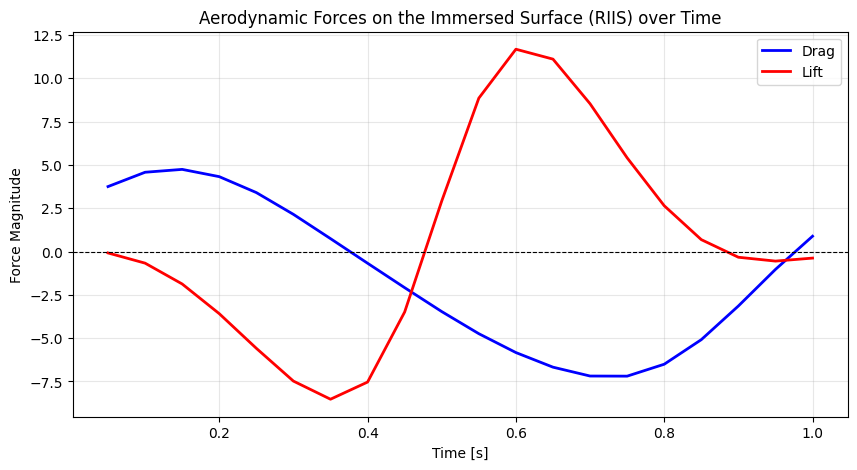

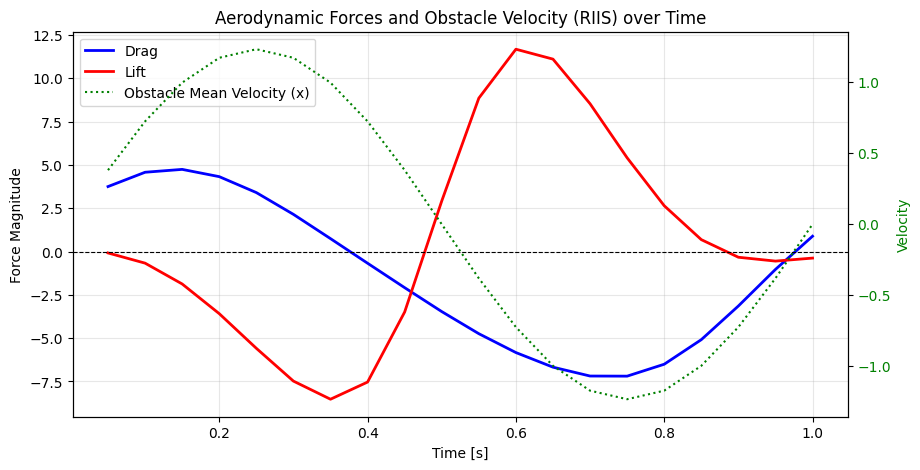

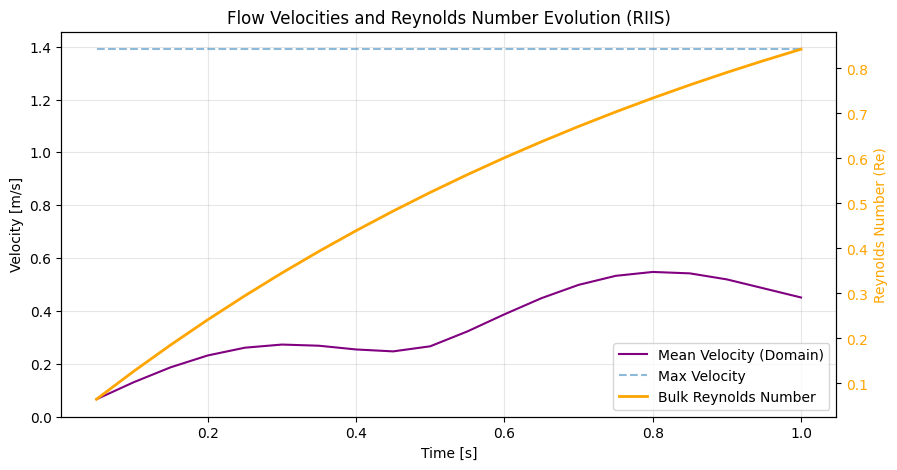

In [ ]:
from firedrake import *
import numpy as np
import os
import matplotlib.pyplot as plt
from firedrake.plot import tripcolor, triplot
from math import pi as PI

# Assumes lineObstacle and rotatingLineObstacle are available in obstacles.py
# from obstacles import lineObstacle, rotatingLineObstacle

# ------- CONFIGURATION ------- #
CONFORMING = False  # If True, switch off RIIS term (R=0) and create mesh conforming to obstacle
MOVING = True       # If True, the immersed obstacle is moving

def savePVD(file_dict, t, uh, ph, phi, delta, vort=None):
    """Save fields to PVD files for Paraview visualization"""
    uh.rename("Velocity")
    ph.rename("Pressure")
    phi.rename("Levelset")
    delta.rename("DiracDelta")

    file_dict['u'].write(uh, time=t)
    file_dict['p'].write(ph, time=t)
    file_dict['phi'].write(phi, time=t)
    file_dict['delta'].write(delta, time=t)
    if vort:
        vort.rename("Vorticity")
        file_dict['vort'].write(vort, time=t)

# ------- PARAMETERS ------- #
Lx, Ly = 3.0, 1.0
x_obs, y_obs = 0.5, 0.5 * Ly
r_obs = 0.1 # Used as characteristic length for Reynolds if needed
n_elements = 200

# ------- MESH ------- #
if not CONFORMING:
    mesh = RectangleMesh(n_elements * 3, n_elements, Lx, Ly)
else:
    # Fallback or specific implementation for conforming mesh if required
    pass

x, y = SpatialCoordinate(mesh)

# Plot of the initial mesh
fig, axes = plt.subplots(figsize=(12, 4))
triplot(mesh, axes=axes,
        interior_kw={'linewidth': 0.1, 'alpha': 0.3},
        boundary_kw={'linewidth': 1.0, 'color': 'black'})
axes.set_aspect('equal')
axes.set_title(f"Mesh {'Conforming' if CONFORMING else 'Rectangular'}")
plt.show()

# ------- DATA ------- #
T = 1.0            # Final time (Matched to RIIS original)
num_steps = 20     # Number of time steps (Matched to RIIS original)
dt = T / num_steps
mu = 0.1
rho = 1.0

# RIIS Penalty Parameters
eps = 8.0 / n_elements
if CONFORMING:
    R = Constant(0.0)
else:
    R = Constant(1000.0)

t_param = Constant(0.0)
f = Constant((0.0, 0.0))
# Parabolic profile: 4 * y * (1 - y) --> Poiseuille Profile
# Temporal Decay: 1.0 - e^(-t) --> Smooth acceleration
inflow_profile = as_vector([(1.0 - exp(-t_param)) * 4.0 * y * (1.0 - y), 0.0])

# ------- FUNCTIONAL SPACES ------- #
V = VectorFunctionSpace(mesh, "CG", 2)
Q = FunctionSpace(mesh, "CG", 1)
W = V * Q  # Mixed Space

sol = Function(W)
uh, ph = sol.subfunctions
uh_n = Function(V)

# Space for vorticity
V_vort = FunctionSpace(mesh, "CG", 1)
vorticity = Function(V_vort, name="vorticity")

# ------- BOUNDARY CONDITIONS ------- #
tag_inflow = 1
tag_bottom = 3
tag_top = 4
tag_outflow = 2

bcs = [DirichletBC(W.sub(0), inflow_profile, tag_inflow), # Inflow
       DirichletBC(W.sub(0), Constant((0, 0)), tag_bottom), # Bottom Wall
       DirichletBC(W.sub(0), Constant((0, 0)), tag_top)]    # Top Wall

# ------- VARIATIONAL FORMULATION ------- #
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

# Define the obstacle (Using rotatingLine as in the original RIIS code)
obstacle = rotatingLineObstacle(mesh, t_param, x_obs, 0.0, x_obs, y_obs, eps)

phi_expr = obstacle.distExpr()
delta_expr = obstacle.delta()
us_expr = as_vector([obstacle.us_x, obstacle.us_y])

# Weak Formulation (RIIS)
a = ( (rho / dt) * inner(u, v) * dx
    + mu * inner(grad(u), grad(v)) * dx
    - div(v) * p * dx
    + div(u) * q * dx
    + (R / eps) * delta_expr * inner(u, v) * dx ) # Resistive surface term

L = ( (rho / dt) * inner(uh_n, v) * dx
    + inner(f, v) * dx
    + (R / eps) * delta_expr * inner(us_expr, v) * dx )

# ------- SETUP OUTPUT ------- #
dir1 = 'conforming' if CONFORMING else 'RIIS'
dir2 = 'moving' if MOVING else 'steady'
R_val = R.values()[0] if not CONFORMING else 0
basedir = f"beam/{dir1}/{dir2}/n{n_elements}_eps{eps:.3f}/"
if not os.path.exists(basedir):
    os.makedirs(basedir)

file_u = File(basedir + "velocity.pvd")
file_p = File(basedir + "pressure.pvd")
file_phi = File(basedir + "phi.pvd")
file_delta = File(basedir + "delta.pvd")
file_vort = File(basedir + "vorticity.pvd")

file_dict = {'u': file_u, 'p': file_p, 'phi': file_phi, 'delta': file_delta, 'vort': file_vort}

# Functions for visualization of results
V_dg = FunctionSpace(mesh, "DG", 1)
phi_plot = Function(V_dg)
delta_plot = Function(V_dg)

# ------- TIME STEPPING ------- #
t = 0.0
uh_n.assign(0.0)

phi_plot.interpolate(phi_expr)
delta_plot.interpolate(delta_expr)

times = []
drags = []
lifts = []
us_x_history = []

D_char = 2 * r_obs # Characteristic length (can be adjusted based on the beam length)
domain_area = Lx * Ly

u_mean_history = []
Re_history = []

savePVD(file_dict, 0.0, uh, ph, phi_plot, delta_plot)

for n in range(num_steps):
    t += dt
    t_param.assign(t)

    # Compute average obstacle velocity over the domain for tracking purposes
    current_us_x = float(assemble(obstacle.us_x * dx(domain=mesh)) / assemble(Constant(1.0) * dx(domain=mesh)))

    # Solve the Linear System
    solve(a == L, sol, bcs=bcs,
          solver_parameters={
              "ksp_type": "gmres",
              "pc_type": "lu",
              "pc_factor_mat_solver_type": "mumps"
          })

    # Compute Vorticity
    vort_expr = uh[1].dx(0) - uh[0].dx(1)
    vorticity.project(vort_expr)

    # Compute Drag and Lift (RIIS Force acting on the fluid interface)
    # F = integral( (R/eps) * delta * (u_s - u) )
    drag = assemble((R / eps) * delta_expr * (us_expr[0] - uh[0]) * dx)
    lift = assemble((R / eps) * delta_expr * (us_expr[1] - uh[1]) * dx)

    times.append(t)
    drags.append(drag)
    lifts.append(lift)
    us_x_history.append(current_us_x)

    # Max Velocity
    max_u = np.max(np.abs(uh.dat.data_ro))

    # Mean Velocity
    u_mean = assemble(sqrt(inner(uh, uh)) * dx) / domain_area

    # Bulk velocity
    u_bulk = float(assemble(uh[0] * ds(tag_inflow)) / Ly)
    # Bulk Reynolds Number
    Re = (rho * u_bulk * D_char) / mu

    u_mean_history.append(u_mean)
    Re_history.append(Re)

    print()
    print(f"▼ Step {n+1:02d} / {num_steps} | Time: {t:4.2f} s")
    print(f"  ├─ Obstacle Velocity --> {current_us_x:8.4f}")
    print(f"  ├─ Drag Force ---------> {drag:8.4f}")
    print(f"  ├─ Lift Force ---------> {lift:8.4f}")
    print(f"  ├─ Mean Velocity ------> {u_mean:8.4f}")
    print(f"  ├─ Bulk Reynolds Num --> {Re:8.4f}")
    print(f"  └─ Max Fluid Velocity -> {max_u:8.4f}")
    print()

    # Match the plotting frequency of Brinkman (every 5 steps)
    if n % 5 == 0:
        fig, axs = plt.subplots(1, 3, figsize=(18, 4))

        col1 = tripcolor(uh, axes=axs[0], cmap="viridis")
        axs[0].set_title(f"Velocity field t={t:.2f}")
        axs[0].set_aspect('equal')
        fig.colorbar(col1, ax=axs[0])

        col2 = tripcolor(ph, axes=axs[1], cmap="coolwarm")
        axs[1].set_title(f"Pressure field t={t:.2f}")
        axs[1].set_aspect('equal')
        fig.colorbar(col2, ax=axs[1])

        col3 = tripcolor(vorticity, axes=axs[2], cmap="RdBu_r")
        axs[2].set_title(f"Vorticity field t={t:.2f}")
        axs[2].set_aspect('equal')
        fig.colorbar(col3, ax=axs[2])

        plt.tight_layout()
        plt.show()

    uh_n.assign(sol.subfunctions[0])

    # Output data
    phi_plot.interpolate(phi_expr)
    delta_plot.interpolate(delta_expr)
    savePVD(file_dict, t, uh, ph, phi_plot, delta_plot, vorticity)

# ------- FINAL FORCES PLOT ------- #

# 1. Just the forces
plt.figure(figsize=(10, 5))
plt.plot(times, drags, label='Drag', color='blue', linewidth=2)
plt.plot(times, lifts, label='Lift', color='red', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Force Magnitude')
plt.title('Aerodynamic Forces on the Immersed Surface (RIIS) over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Forces and Obstacle velocity
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(times, drags, label='Drag', color='blue', linewidth=2)
ax1.plot(times, lifts, label='Lift', color='red', linewidth=2)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Force Magnitude')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(times, us_x_history, label='Obstacle Mean Velocity (x)', color='green', linewidth=1.5, linestyle=':')
ax2.set_ylabel('Velocity', color='green')
ax2.tick_params(axis='y', labelcolor='green')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Aerodynamic Forces and Obstacle Velocity (RIIS) over Time')
plt.show()

# ------- PLOT: REYNOLDS and MEAN VELOCITY ------- #
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(times, u_mean_history, label='Mean Velocity (Domain)', color='purple')
ax1.plot(times, [np.max(np.abs(uh.dat.data_ro))]*len(times), '--', label='Max Velocity', alpha=0.5)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Velocity [m/s]')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(times, Re_history, label='Bulk Reynolds Number', color='orange', linewidth=2)
ax2.set_ylabel('Reynolds Number (Re)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')

plt.title('Flow Velocities and Reynolds Number Evolution (RIIS)')
plt.show()

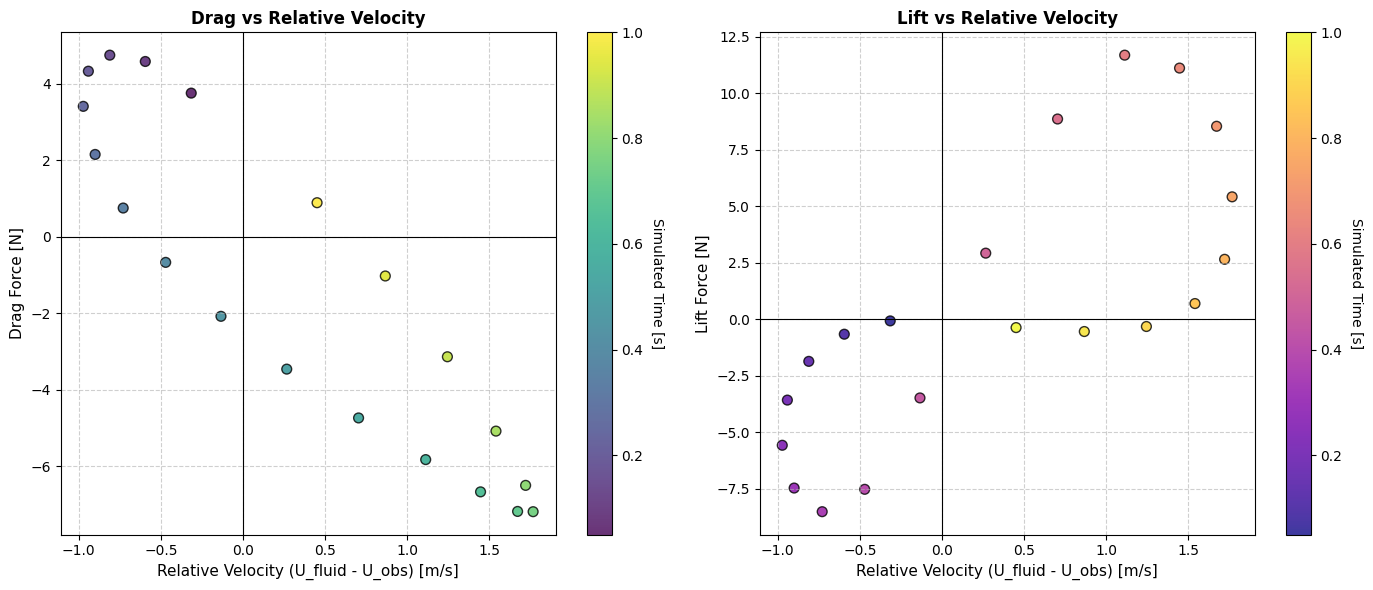


Peak Analysis:
 - Maximum absolute Drag: -7.1938 N (occurs at V_rel = 1.7664 m/s, t = 0.75 s)
 - Maximum absolute Lift: 11.6823 N (occurs at V_rel = 1.1122 m/s, t = 0.60 s)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Convert lists to NumPy arrays for vectorized operations
# Using the vectors saved during the time-stepping loop
v_obs = np.array(us_x_history)
v_fluid = np.array(u_mean_history)
times_arr = np.array(times)
drags_arr = np.array(drags)
lifts_arr = np.array(lifts)

# 2. Compute Relative Velocity
# If the obstacle moves to the right (v_obs > 0), the relative fluid velocity decreases.
v_rel = v_fluid - v_obs

# 3. Create side-by-side plots (Drag and Lift)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Using a scatter plot with a time-based colormap to visualize
# the temporal evolution (direction of the hysteresis cycle)

# --- Drag vs Relative Velocity Plot ---
sc1 = ax1.scatter(v_rel, drags_arr, c=times_arr, cmap='viridis', edgecolor='k', alpha=0.8, s=50)
ax1.set_title('Drag vs Relative Velocity', fontsize=12, fontweight='bold')
ax1.set_xlabel('Relative Velocity (U_fluid - U_obs) [m/s]', fontsize=11)
ax1.set_ylabel('Drag Force [N]', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.axvline(0, color='black', linewidth=0.8) # Zero velocity axis
ax1.axhline(0, color='black', linewidth=0.8) # Zero force axis

# --- Lift vs Relative Velocity Plot ---
sc2 = ax2.scatter(v_rel, lifts_arr, c=times_arr, cmap='plasma', edgecolor='k', alpha=0.8, s=50)
ax2.set_title('Lift vs Relative Velocity', fontsize=12, fontweight='bold')
ax2.set_xlabel('Relative Velocity (U_fluid - U_obs) [m/s]', fontsize=11)
ax2.set_ylabel('Lift Force [N]', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.axhline(0, color='black', linewidth=0.8)

# --- Lift and Drag coefficients ---

# Add colorbars to map colors to simulation time steps
cbar1 = fig.colorbar(sc1, ax=ax1)
cbar1.set_label('Simulated Time [s]', rotation=270, labelpad=15)

cbar2 = fig.colorbar(sc2, ax=ax2)
cbar2.set_label('Simulated Time [s]', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# 4. Compute optional summary metrics
drag_max_idx = np.argmax(np.abs(drags_arr))
print()
print("Peak Analysis:")
print(f" - Maximum absolute Drag: {drags_arr[drag_max_idx]:.4f} N (occurs at V_rel = {v_rel[drag_max_idx]:.4f} m/s, t = {times_arr[drag_max_idx]:.2f} s)")

lift_max_idx = np.argmax(np.abs(lifts_arr))
print(f" - Maximum absolute Lift: {lifts_arr[lift_max_idx]:.4f} N (occurs at V_rel = {v_rel[lift_max_idx]:.4f} m/s, t = {times_arr[lift_max_idx]:.2f} s)")

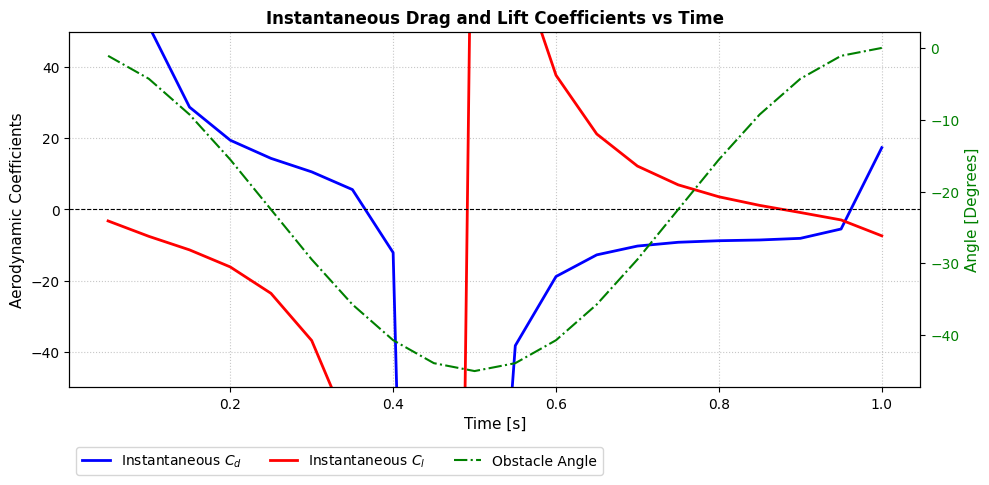

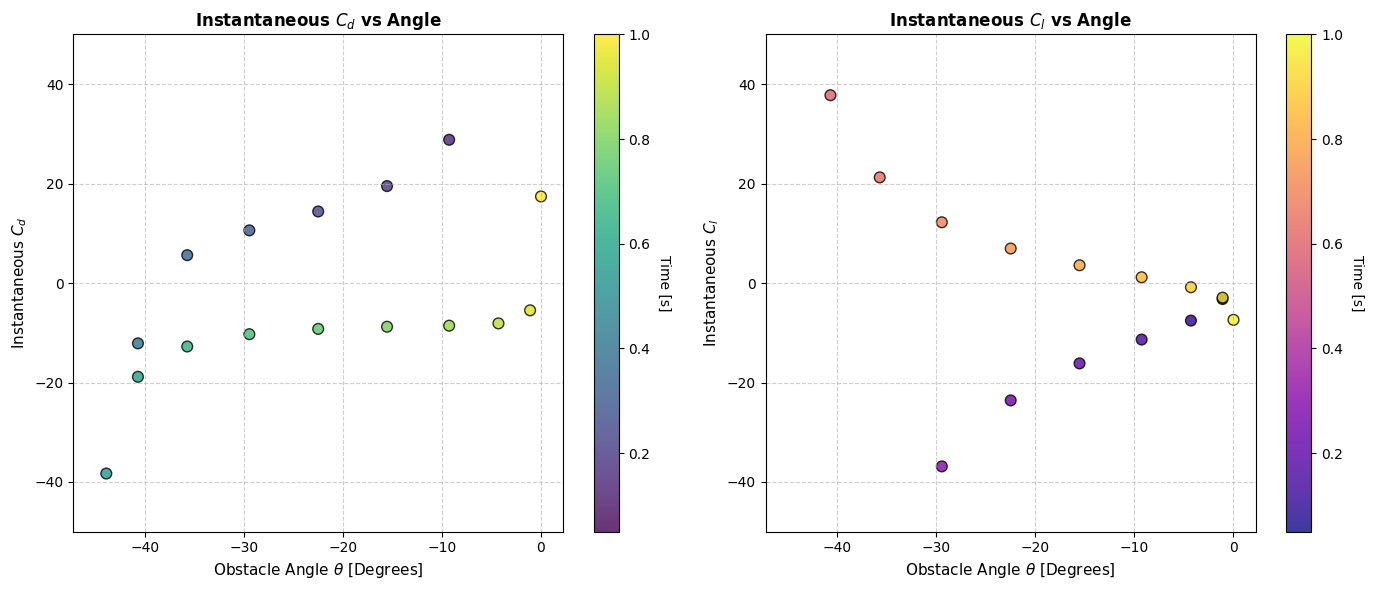

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Aerodynamic Reference Parameters
rho = 1.0           # Fluid density
D_char = 0.5        # Characteristic length (length of the beam)

# 2. Reconstruct the Kinematics (Angle of the obstacle)
theta_max_rad = np.pi / 4.0
theta_rad = -0.5 * (1 - np.cos(2 * np.pi * times_arr)) * theta_max_rad
theta_deg = np.degrees(theta_rad)

# 3. Compute Instantaneous Dynamic Pressure
# We use v_rel = v_fluid - v_obs computed in the previous step.
# Epsilon prevents division by zero when the relative velocity crosses 0 m/s.
epsilon = 1e-4
q_dynamic_arr = 0.5 * rho * (v_rel**2) * D_char + epsilon

# 4. Compute Instantaneous Aerodynamic Coefficients
Cd_arr = drags_arr / q_dynamic_arr
Cl_arr = lifts_arr / q_dynamic_arr

# =========================================================
# PLOT 1: Instantaneous Coefficients vs Time
# =========================================================
fig1, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(times_arr, Cd_arr, label='Instantaneous $C_d$', color='blue', linewidth=2)
ax1.plot(times_arr, Cl_arr, label='Instantaneous $C_l$', color='red', linewidth=2)

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Time [s]', fontsize=11)
ax1.set_ylabel('Aerodynamic Coefficients', fontsize=11)
ax1.set_title('Instantaneous Drag and Lift Coefficients vs Time', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.7)

# Limit y-axis to cut off the mathematical singularities near V_rel = 0
ax1.set_ylim([-50, 50])

# Add a secondary axis for the obstacle angle
ax1_twin = ax1.twinx()
ax1_twin.plot(times_arr, theta_deg, label='Obstacle Angle', color='green', linewidth=1.5, linestyle='-.')
ax1_twin.set_ylabel('Angle [Degrees]', color='green', fontsize=11)
ax1_twin.tick_params(axis='y', labelcolor='green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0.0, -0.15), ncol=3)

plt.tight_layout()
plt.show()

# =========================================================
# PLOT 2: Instantaneous Coefficients vs Angle (Phase Space)
# =========================================================
fig2, (ax2_d, ax2_l) = plt.subplots(1, 2, figsize=(14, 6))

# Cd vs Angle
sc_d = ax2_d.scatter(theta_deg, Cd_arr, c=times_arr, cmap='viridis', edgecolor='k', s=60, alpha=0.8)
ax2_d.set_title('Instantaneous $C_d$ vs Angle', fontsize=12, fontweight='bold')
ax2_d.set_xlabel('Obstacle Angle $\\theta$ [Degrees]', fontsize=11)
ax2_d.set_ylabel('Instantaneous $C_d$', fontsize=11)
ax2_d.grid(True, linestyle='--', alpha=0.6)
ax2_d.set_ylim([-50, 50]) # Cut off singularity spikes

# Cl vs Angle
sc_l = ax2_l.scatter(theta_deg, Cl_arr, c=times_arr, cmap='plasma', edgecolor='k', s=60, alpha=0.8)
ax2_l.set_title('Instantaneous $C_l$ vs Angle', fontsize=12, fontweight='bold')
ax2_l.set_xlabel('Obstacle Angle $\\theta$ [Degrees]', fontsize=11)
ax2_l.set_ylabel('Instantaneous $C_l$', fontsize=11)
ax2_l.grid(True, linestyle='--', alpha=0.6)
ax2_l.set_ylim([-50, 50]) # Cut off singularity spikes

# Add Colorbars
cbar_d = fig2.colorbar(sc_d, ax=ax2_d)
cbar_d.set_label('Time [s]', rotation=270, labelpad=15)

cbar_l = fig2.colorbar(sc_l, ax=ax2_l)
cbar_l.set_label('Time [s]', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()